## 4. Investigate fragmented replay content by summing placefield

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import cupy as cp
import numpy as np
import numpy.ma as ma
import datajoint as dj
import spyglass as nd
import pandas as pd
import matplotlib.pyplot as plt
import json
import multiprocessing

# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
import spyglass.spikesorting.v0 as ss

from spyglass.spikesorting.v0 import (SortGroup, 
                                    SortInterval,
                                    SpikeSortingPreprocessingParameters,
                                    SpikeSortingRecording, 
                                    SpikeSorterParameters,
                                    SpikeSortingRecordingSelection,
                                    ArtifactDetectionParameters, ArtifactDetectionSelection,
                                    ArtifactRemovedIntervalList, ArtifactDetection,
                                      SpikeSortingSelection, SpikeSorting,
                                   CuratedSpikeSortingSelection,CuratedSpikeSorting,Curation)
from spyglass.spikesorting.v0.curation_figurl import CurationFigurl,CurationFigurlSelection
from spyglass.spikesorting.v0.spikesorting_curation import MetricParameters,MetricSelection,QualityMetrics
from spyglass.spikesorting.v0.spikesorting_curation import WaveformParameters,WaveformSelection,Waveforms
from spyglass.common.common_position import IntervalPositionInfo, IntervalPositionInfoSelection,IntervalLinearizedPosition

from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from pprint import pprint
from spyglass.shijiegu.ripple_detection import removeDataBeforeTrial1
from spyglass.shijiegu.helpers import interpolate_to_new_time
from spyglass.shijiegu.placefield import place_field,placefield_to_peak1dloc
from spyglass.shijiegu.Analysis_SGU import DecodeResultsLinear
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)
warnings.filterwarnings('ignore')

[2025-11-11 14:53:37,089][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [5]:
from spyglass.shijiegu.helpers import interval_union
from spyglass.shijiegu.Analysis_SGU import TrialChoice,RippleTimes,EpochPos,ExtendedRippleTimes,RippleTimesWithDecode
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.singleUnit import (do_mountainSort,electrode_unit,RippleTime2FiringRate,findWaveForms,RippleTime2Index,
                            )
from spyglass.shijiegu.fragmented import (permute_frag_cont,find_spike_count_ratio,
                            get_nwb_units,find_firing_cross_correlation,classify_cells)
from spyglass.shijiegu.placefield import cell_by_arm

In [13]:
from spyglass.shijiegu.singleUnit import (session_unit,RippleTime2FiringRate,
                                          find_spikes,xcorr)
from spyglass.shijiegu.fragmented_place_sum import sum_place_field, sum_place_field_by_weight

In [14]:
outputFolder='/cumulus/shijie/recording_pilot/eliot/FragmentedReplay/'
isExist = os.path.exists(outputFolder)
if not isExist:
    os.makedirs(outputFolder)

In [153]:
nwb_copy_file_name = "lewis20240109_.nwb"
#nwb_copy_file_name = "eliot20221021_.nwb"

In [154]:
run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
lewis20240109_ 1         01_Rev2Sleep1  pos 0 valid ti
lewis20240109_ 2         02_Rev2Session pos 1 valid ti
lewis20240109_ 3         03_Rev2Sleep2  pos 2 valid ti
lewis20240109_ 4         04_Rev2Session pos 3 valid ti
lewis20240109_ 5         05_Rev2Sleep3  pos 4 valid ti
lewis20240109_ 6         06_Rev2Session pos 5 valid ti
lewis20240109_ 7         07_Rev2Sleep4  pos 6 valid ti
lewis20240109_ 8         08_Rev2Session pos 7 valid ti
lewis20240109_ 9         09_Rev2Sleep5  pos 8 valid ti
 (Total: 9)



In [155]:
epoch_num = 0
session_name = run_session_names[epoch_num]
pos_name = pos_session_names[epoch_num]
print(session_name)

02_Rev2Session1


In [156]:
# load spikes
nwb_units_all, sort_group_ids_with_good_cell = session_unit(nwb_copy_file_name,session_name,curation_id = 1)

# load ripple
try:
    ripple_times = pd.DataFrame((RippleTimesWithDecode & 
                             {'nwb_file_name': nwb_copy_file_name,
                              'interval_list_name': session_name,
                              'encoding_set':"2Dheadspeed_above_4"}).fetch1('ripple_times'))
except:
    ripple_times = pd.read_pickle((RippleTimesWithDecode & 
                             {'nwb_file_name': nwb_copy_file_name,
                              'interval_list_name': session_name,
                              'encoding_set':"2Dheadspeed_above_4"}).fetch1('ripple_times'))
    



[2025-11-12 22:07:39,782][WARNING]: Skipped checksum for file with hash: d397de4d-b956-a6b8-f13f-a720e0ffb49d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_I5XI9DA3D8.nwb
[2025-11-12 22:07:39,800][WARNING]: Skipped checksum for file with hash: d397de4d-b956-a6b8-f13f-a720e0ffb49d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_I5XI9DA3D8.nwb
[2025-11-12 22:07:39,805][WARNING]: Skipped checksum for file with hash: d397de4d-b956-a6b8-f13f-a720e0ffb49d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_I5XI9DA3D8.nwb
[2025-11-12 22:07:48,951][WARNING]: Skipped checksum for file with hash: 7fa7a96b-96e8-bb28-2e8a-6aecb69b2400, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_VBRYBZUX8E.nwb
[2025-11-12 22:07:48,966][WARNING]: Skipped checksum for file with hash: 7fa7a96b-96e8-bb28-2e8a-6aecb69b2400, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_VBRYBZUX8E.nwb
[2025-11-12 22:07:48,970][WARNING]: Skipped checksum for file with hash: 7f

In [157]:
(RippleTimesWithDecode & 
                             {'nwb_file_name': nwb_copy_file_name, 'interval_list_name': session_name})

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,decode_threshold_method a name for this thresholding method,ripple_times ripple times within that interval
lewis20240109_.nwb,02_Rev2Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,MUA_M05SD,=BLOB=


In [158]:
# load place field

cell_list = []
for e in sort_group_ids_with_good_cell:
    for u in nwb_units_all[e].index:
        cell_list.append((e, u))
        
placefields = {}
mobility_spike_counts = {}
all_spike_counts = {}
peak_frs = {}
for row_ind in range(len(cell_list)):
    print(row_ind)
    e = cell_list[row_ind][0]
    u = cell_list[row_ind][1]
    placefield, peak_fr, xbins, ybins, mobility_spike_count, all_spike_count = place_field(nwb_copy_file_name, session_name, pos_name, e, u)
    placefields[(e,u)] = placefield
    peak_frs[(e,u)] = peak_fr
    mobility_spike_counts[(e,u)] = mobility_spike_count
    all_spike_counts[(e,u)] = all_spike_count


[2025-11-12 22:13:57,116][WARNING]: Skipped checksum for file with hash: 778b344b-ccc7-17e7-4057-f47c4c805051, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_64X0NRA0JZ.nwb
[2025-11-12 22:13:57,129][WARNING]: Skipped checksum for file with hash: 778b344b-ccc7-17e7-4057-f47c4c805051, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_64X0NRA0JZ.nwb
[2025-11-12 22:13:57,134][WARNING]: Skipped checksum for file with hash: 778b344b-ccc7-17e7-4057-f47c4c805051, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_64X0NRA0JZ.nwb


0


[2025-11-12 22:14:06,420][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:14:06,437][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:14:06,442][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb


spike num: 4596


[2025-11-12 22:14:15,462][WARNING]: Skipped checksum for file with hash: 6cfcf895-2e2b-bb17-c3d1-9422e1618213, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_R4LWKFUE59.nwb
[2025-11-12 22:14:15,481][WARNING]: Skipped checksum for file with hash: 6cfcf895-2e2b-bb17-c3d1-9422e1618213, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_R4LWKFUE59.nwb
[2025-11-12 22:14:15,485][WARNING]: Skipped checksum for file with hash: 6cfcf895-2e2b-bb17-c3d1-9422e1618213, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_R4LWKFUE59.nwb
[2025-11-12 22:14:24,904][WARNING]: Skipped checksum for file with hash: 778b344b-ccc7-17e7-4057-f47c4c805051, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_64X0NRA0JZ.nwb
[2025-11-12 22:14:24,915][WARNING]: Skipped checksum for file with hash: 778b344b-ccc7-17e7-4057-f47c4c805051, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_64X0NRA0JZ.nwb
[2025-11-12 22:14:24,919][WARNING]: Skipped checksum for file with hash: 77

...

263
spike num: 1686
264


[2025-11-12 22:21:16,717][WARNING]: Skipped checksum for file with hash: 35603a53-5997-4395-d776-617f968ec39d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_CNBXJJYCAT.nwb
[2025-11-12 22:21:16,723][WARNING]: Skipped checksum for file with hash: 35603a53-5997-4395-d776-617f968ec39d, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_CNBXJJYCAT.nwb
[2025-11-12 22:21:16,744][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:21:16,762][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:21:16,767][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:21:16,793][WARNING]: Skipped checksum for file with hash: 6c

spike num: 3151
265
spike num: 1977


[2025-11-12 22:21:16,950][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:21:16,966][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:21:16,971][WARNING]: Skipped checksum for file with hash: a728061b-c9b4-bb05-a00b-e3fdbb14dbce, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_NN7QH7G89U.nwb
[2025-11-12 22:21:16,996][WARNING]: Skipped checksum for file with hash: 6cfcf895-2e2b-bb17-c3d1-9422e1618213, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_R4LWKFUE59.nwb
[2025-11-12 22:21:17,013][WARNING]: Skipped checksum for file with hash: 6cfcf895-2e2b-bb17-c3d1-9422e1618213, and path: /stelmo/nwb/analysis/lewis20240109/lewis20240109_R4LWKFUE59.nwb
[2025-11-12 22:21:17,017][WARNING]: Skipped checksum for file with hash: 6c

266
spike num: 932


In [159]:
all_cells = list(placefields.keys())

In [160]:
# classify cells
count_ratio, count_ratio_dict, firing_rate_F, firing_rate_C, unit_name = find_spike_count_ratio(nwb_units_all,ripple_times)
cont_ind = np.array(count_ratio) < 0.01
cont_ind = np.argwhere(cont_ind).ravel()
cont_units = [unit_name[i] for i in cont_ind]
cont_count_ratio = [count_ratio[i] for i in cont_ind]

frag_ind = np.array(count_ratio) > 2
frag_ind = np.argwhere(frag_ind).ravel()
frag_units = [unit_name[i] for i in frag_ind]
frag_count_ratio = [count_ratio[i] for i in frag_ind]

In [128]:
ripple_times

,start_time,end_time,animal_location,trial_number,cont_intvl,frag_intvl,cont_intvl_replay,duration,mean_zscore,median_zscore,max_zscore,min_zscore,max_speed,min_speed,median_speed,mean_speed
1,1.666383e+09,1.666383e+09,home,2,"[[1666383001.501959, 1666383001.8699594]]",[],[[2]],0.370,0.535145,0.109575,3.987851,-1.133144,0.735902,0.050214,0.298428,0.356661
2,1.666383e+09,1.666383e+09,home,2,"[[1666383009.397956, 1666383009.6919558]]",[],[[0]],0.297,NaN,NaN,NaN,NaN,6.033348,0.387038,2.766949,2.934517
3,1.666383e+09,1.666383e+09,home,3,"[[1666383044.5959408, 1666383044.7919407], [16...","[[1666383044.857941, 1666383044.9119408]]","[[1], [], []]",0.408,1.421459,0.481448,7.846824,-0.982388,0.173548,0.173525,0.173547,0.173546
4,1.666383e+09,1.666383e+09,home,3,"[[1666383046.0619402, 1666383046.2359402], [16...","[[1666383046.23794, 1666383046.27194]]","[[0], []]",0.289,0.218065,-0.023539,4.383852,-1.107105,0.173549,0.173547,0.173548,0.173548
5,1.666383e+09,1.666383e+09,well3,3,"[[1666383061.4819336, 1666383061.5559337], [16...","[[1666383061.5579336, 1666383061.6279335], [16...","[[], [], []]",0.373,0.914539,0.596194,3.814605,-0.846066,0.050467,0.050466,0.050467,0.050467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,1.666385e+09,1.666385e+09,home,78,"[[1666385109.1570506, 1666385109.5190504], [16...","[[1666385109.5210505, 1666385109.5430503]]","[[2], [0]]",0.527,0.367221,0.060854,3.736403,-1.142059,0.681666,0.681650,0.681662,0.681660
142,1.666385e+09,1.666385e+09,home,78,"[[1666385112.0970492, 1666385112.237049], [166...","[[1666385112.2390492, 1666385112.373049]]","[[0], []]",0.400,2.833871,0.106666,28.721109,-1.002707,0.681666,0.681650,0.681663,0.681660
143,1.666385e+09,1.666385e+09,home,78,"[[1666385112.825049, 1666385113.1630487]]",[],[[2]],0.339,0.086124,-0.133691,3.008300,-1.127472,0.681666,0.681650,0.681661,0.681659
144,1.666385e+09,1.666385e+09,home,80,"[[1666385158.599029, 1666385158.813029], [1666...",[],"[[0], [0]]",0.339,0.505643,0.048653,3.498120,-1.219847,0.407346,0.407343,0.407345,0.407345


In [161]:
def find_cells_in_ripple(nwb_units_all, cell_list, intvl):
    firing_count, _ = find_spikes(nwb_units_all, cell_list, intvl)

    firing_count = firing_count.ravel()
        
    activated_cells = np.array(cell_list)[firing_count > 0]
    weights = firing_count[firing_count > 0]

    return activated_cells, weights

In [162]:
def plot_sum_place_field_by_ripple(ripple_ID, ripple_times, nwb_units_all, all_cells, placefields):
    placefield_sum_all = []
    
    intvls = ripple_times.loc[ripple_ID].frag_intvl
    trial = ripple_times.loc[ripple_ID].trial_number
    location = ripple_times.loc[ripple_ID].animal_location
    if len(intvls) == 0:
        return None
    
    for intvl_ind in range(intvls.shape[0]):
        intvl = intvls[intvl_ind]
        
        duration = str(round(float(np.diff(intvl))*1000,1)) + ' ms'

        activated_cells, weights = find_cells_in_ripple(nwb_units_all, all_cells, intvl)
        if len(activated_cells) == 0:
            continue
        placefield_sum, cell_num = sum_place_field_by_weight(placefields, activated_cells, weights)
        placefield_sum_all.append(placefield_sum)

        if cell_num > 2:
                        
            fig, axes = plt.subplots(1,1,figsize = (3,3),squeeze = False)
            axes[0,0].imshow(placefield_sum)
            axes[0,0].set_axis_off()
            axes[0,0].set_title('animal at: '+location+
                '\ntrial '+str(trial)+' ripple '+str(ripple_ID)+' interval '+ str(intvl_ind)+' '+duration+
                                        '\n'+str(cell_num)+' cells')
    return placefield_sum_all

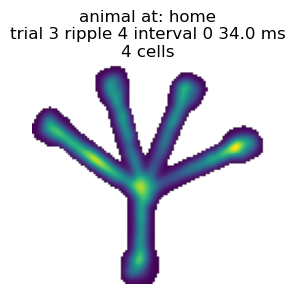

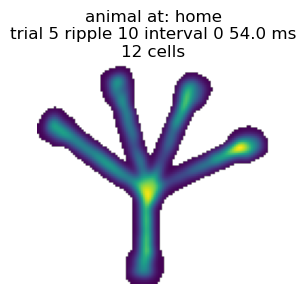

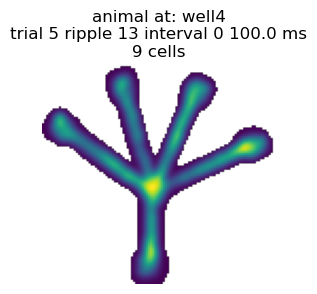

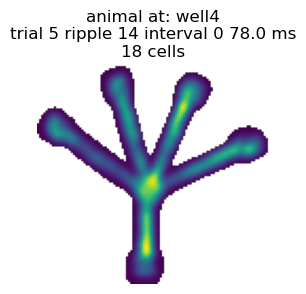

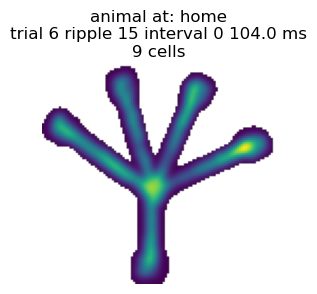

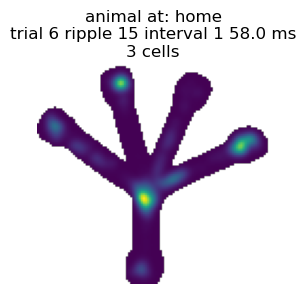

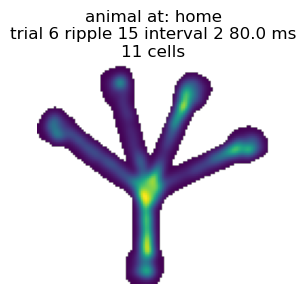

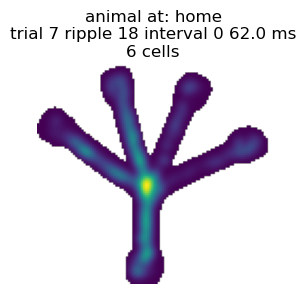

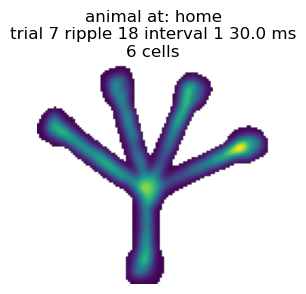

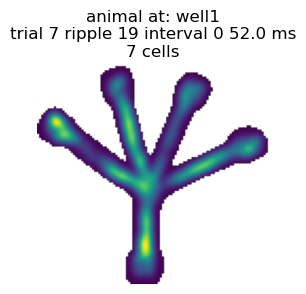

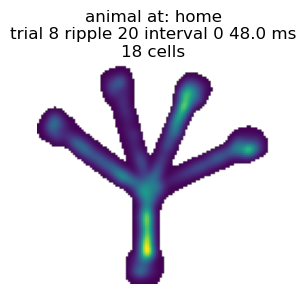

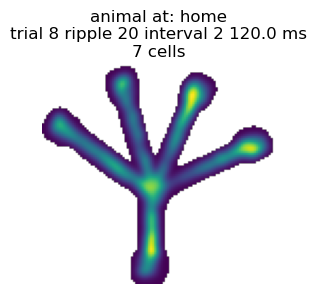

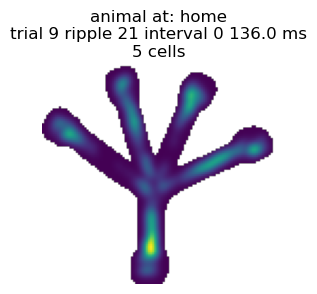

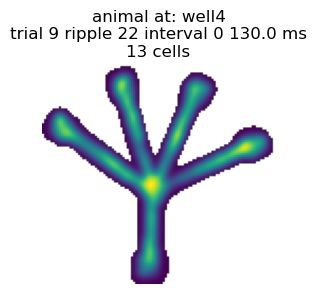

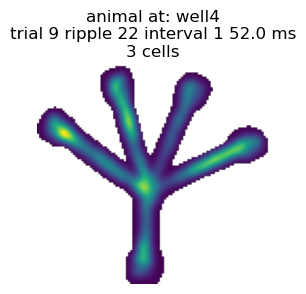

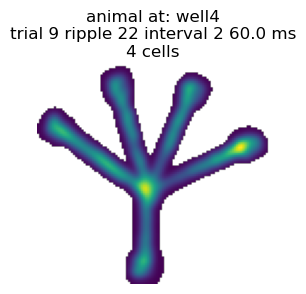

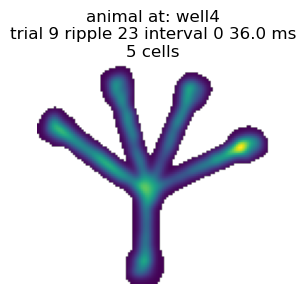

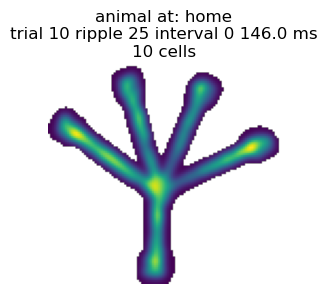

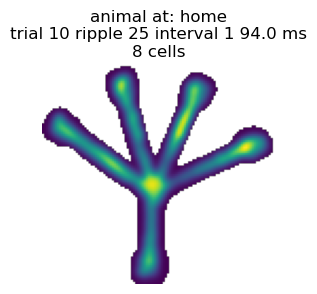

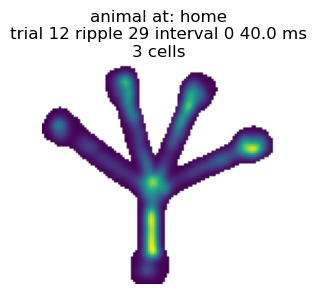

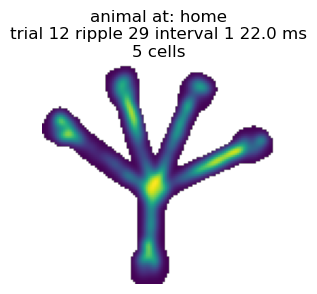

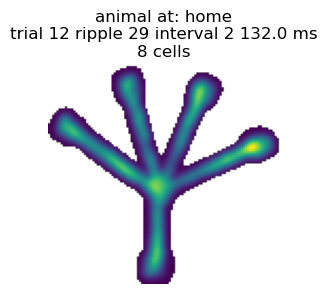

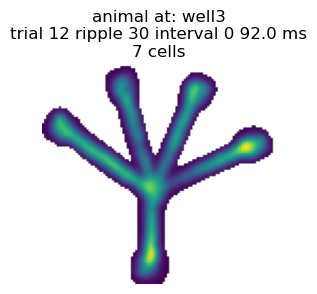

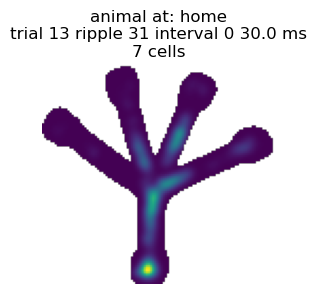

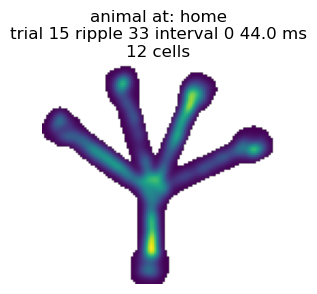

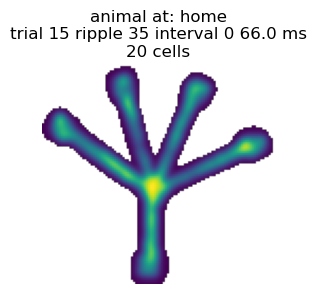

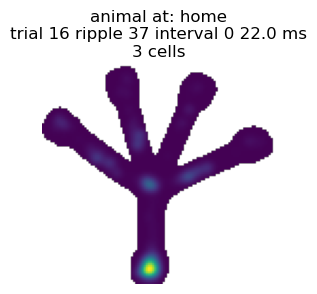

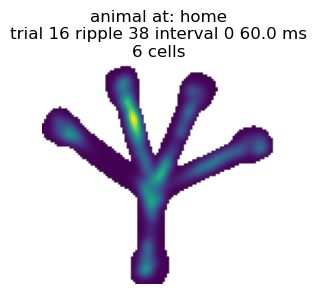

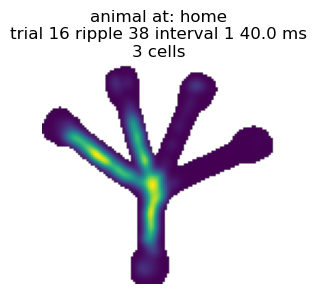

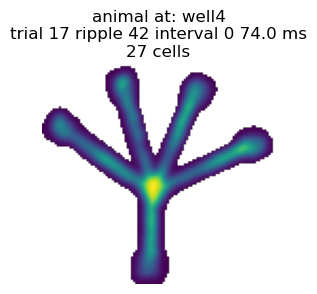

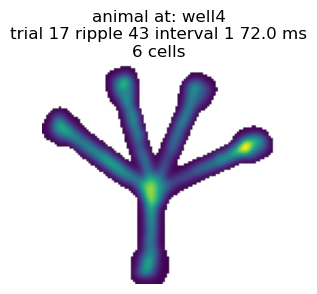

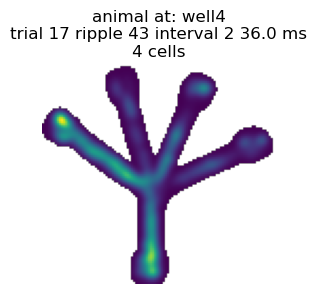

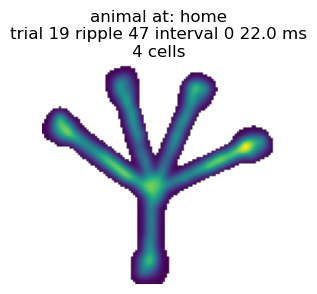

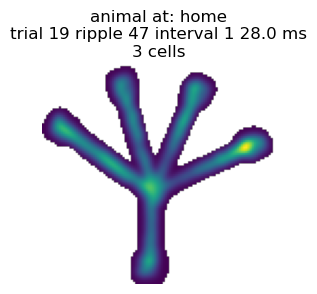

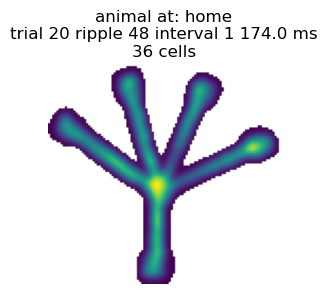

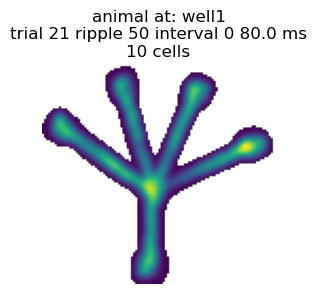

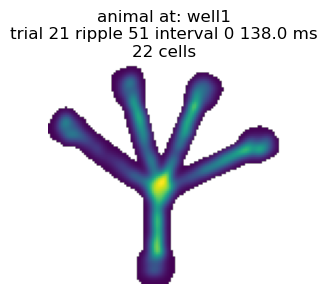

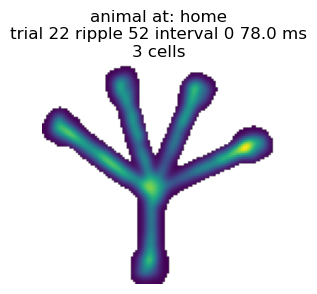

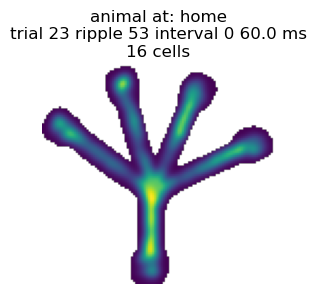

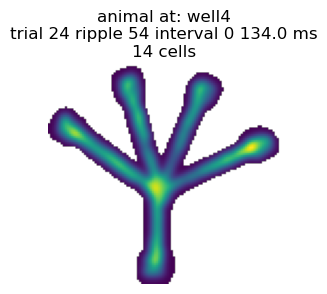

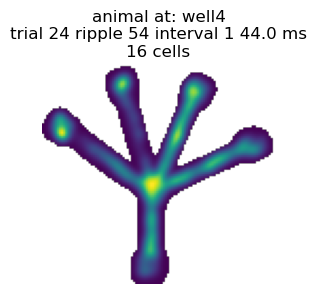

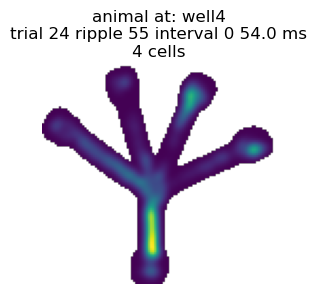

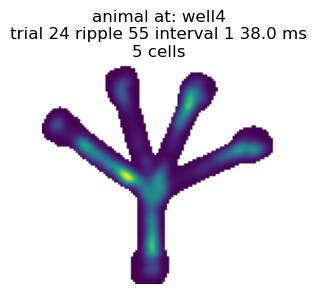

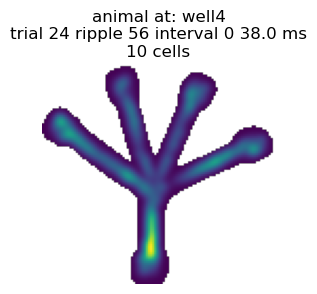

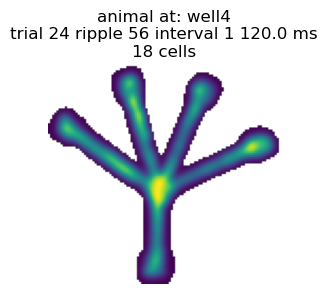

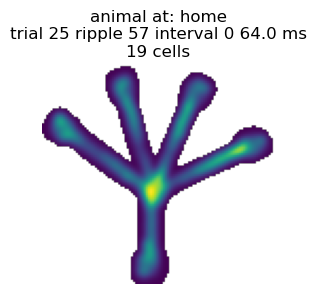

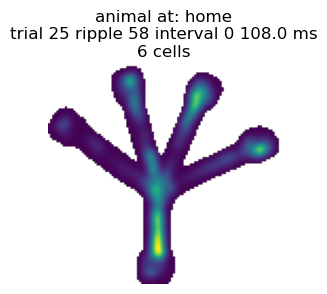

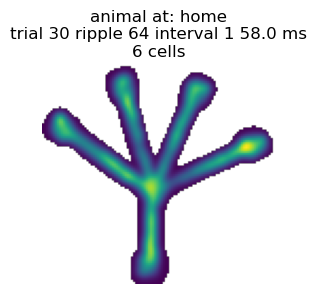

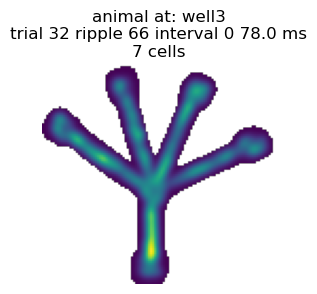

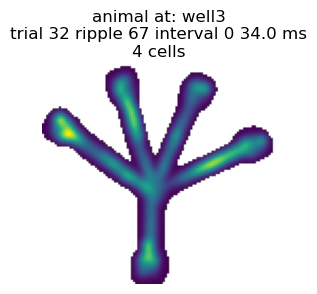

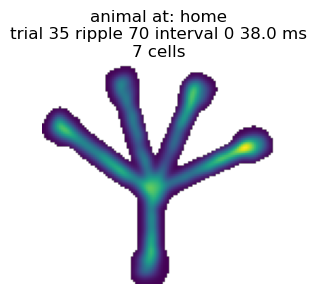

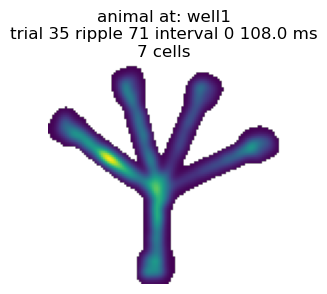

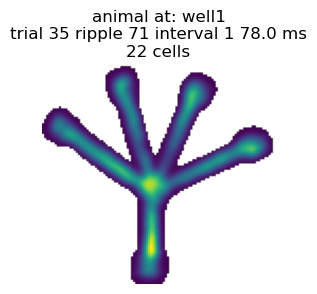

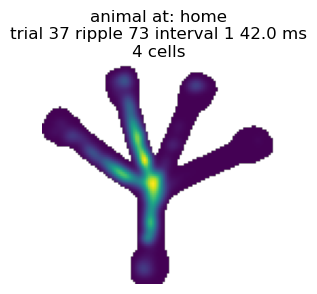

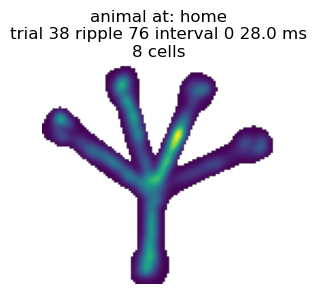

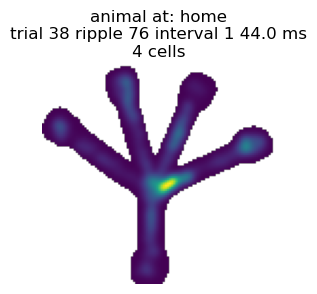

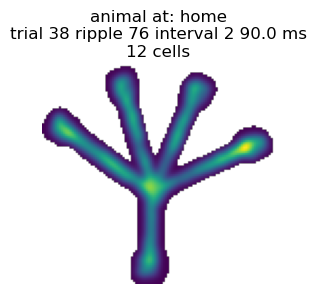

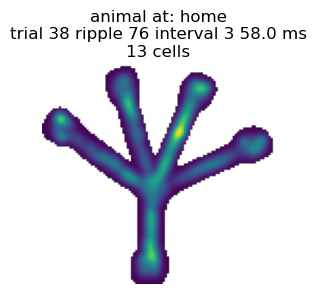

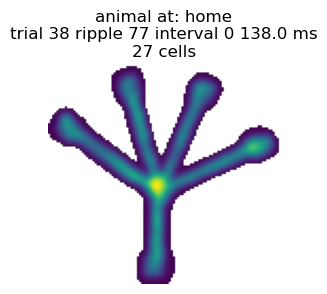

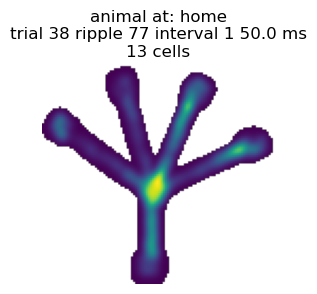

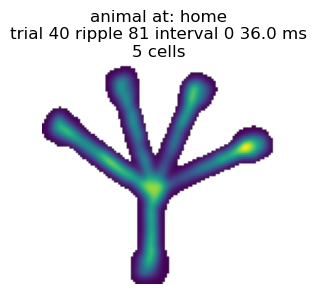

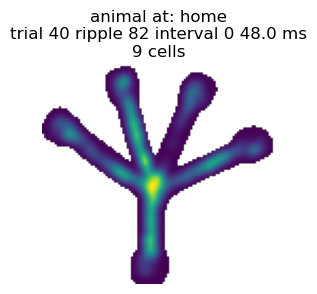

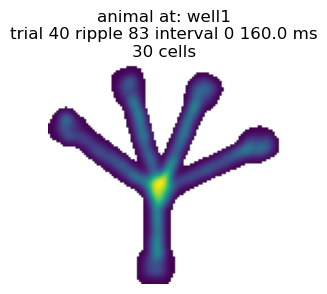

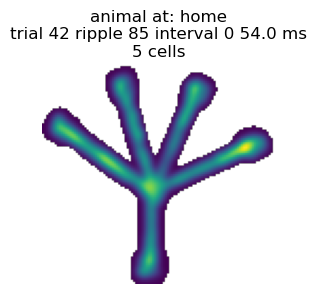

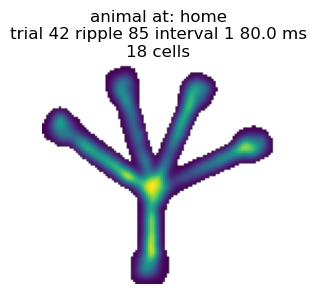

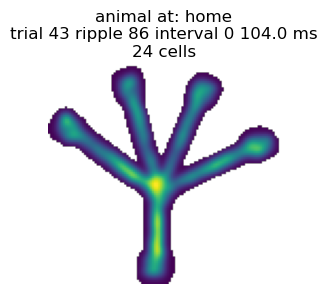

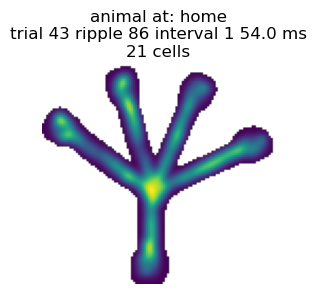

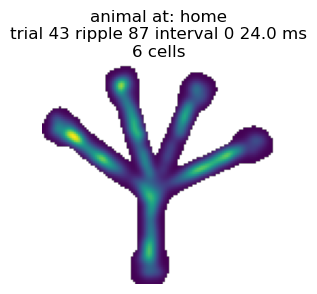

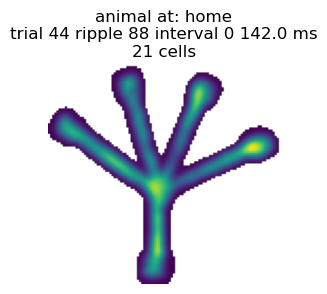

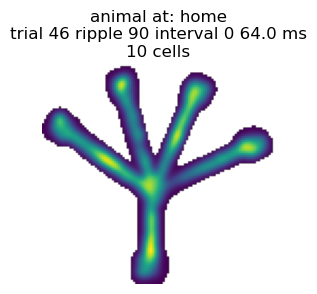

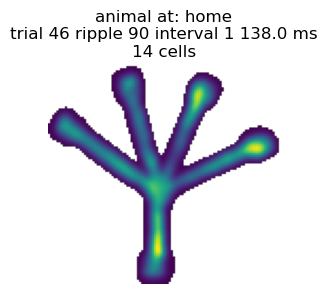

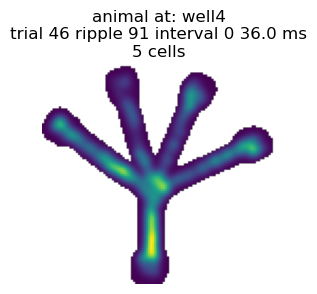

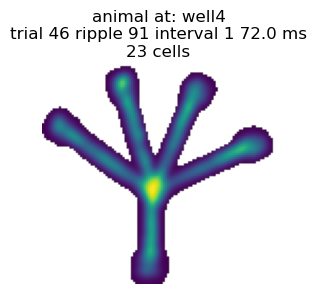

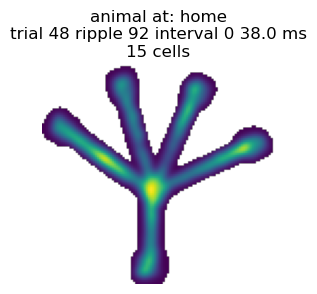

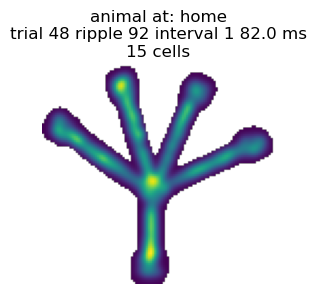

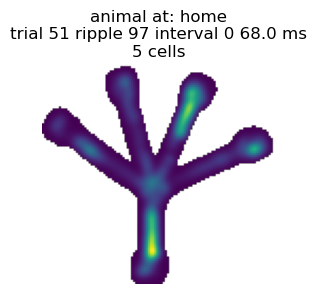

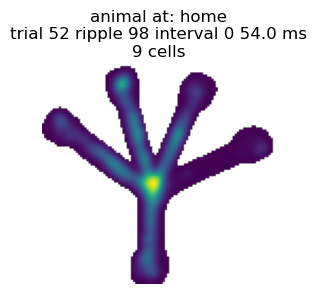

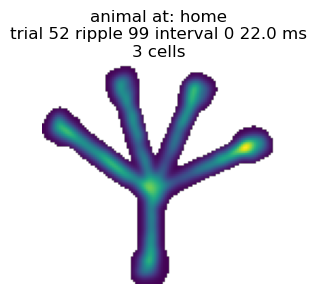

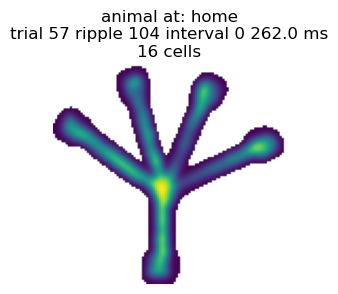

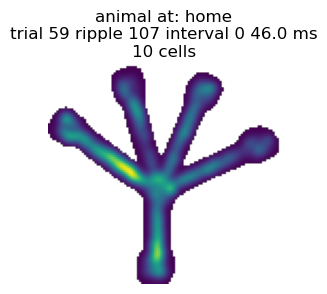

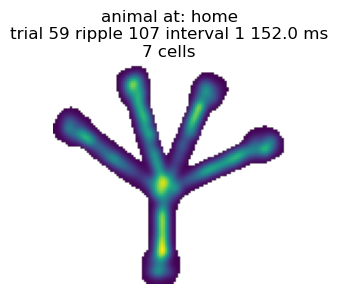

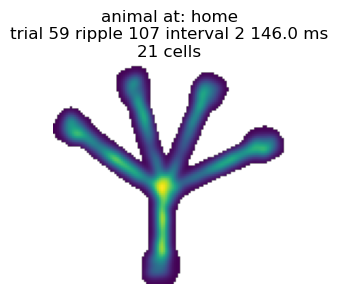

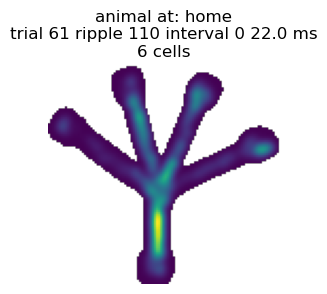

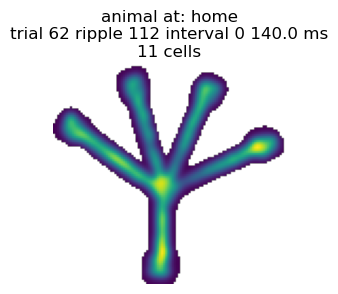

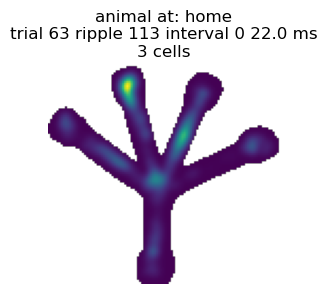

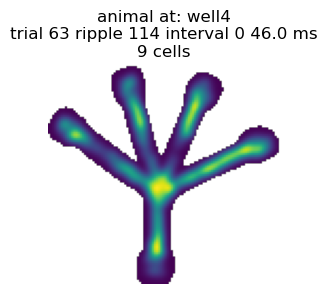

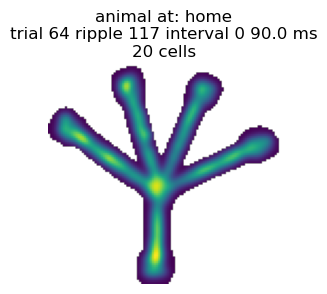

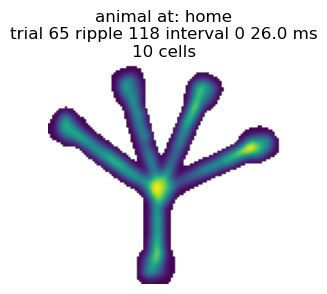

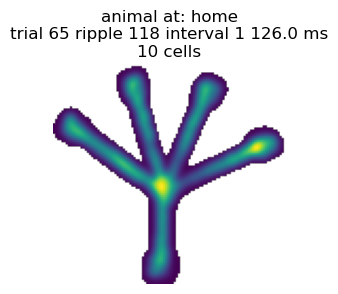

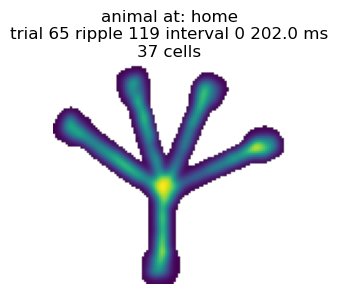

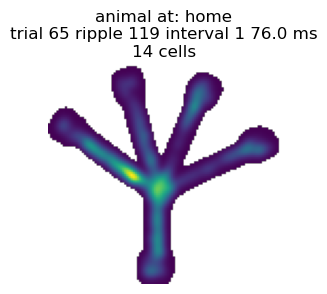

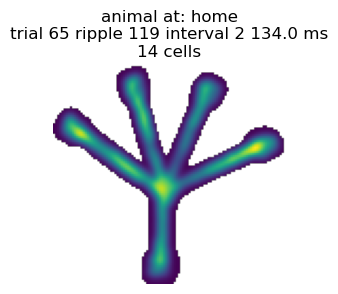

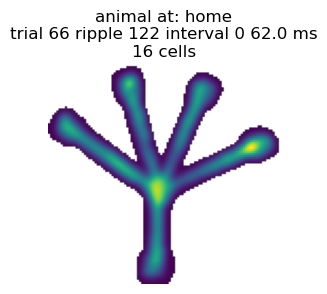

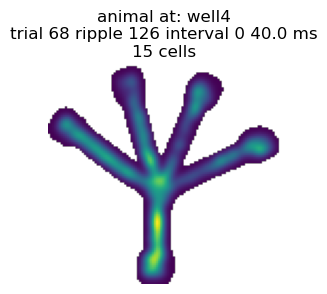

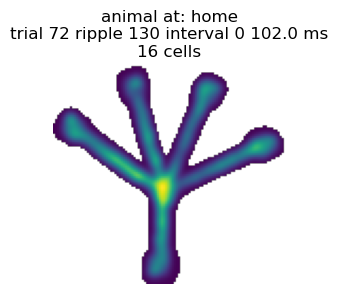

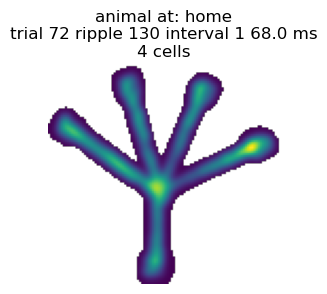

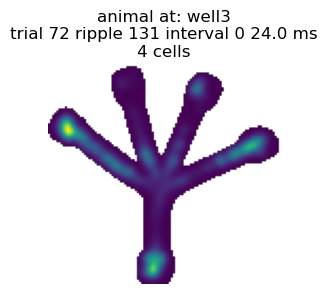

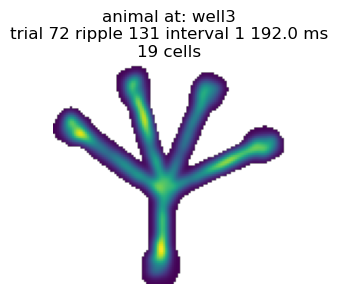

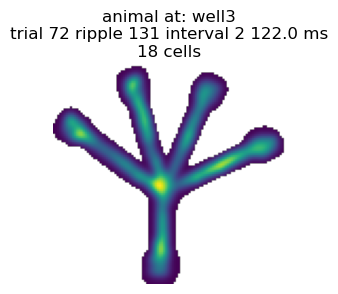

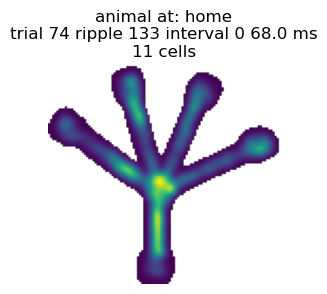

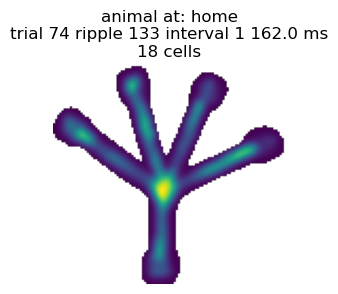

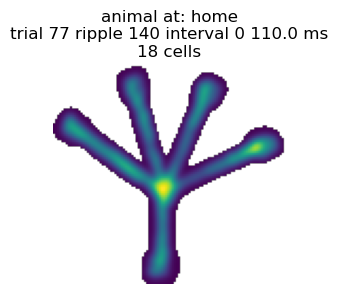

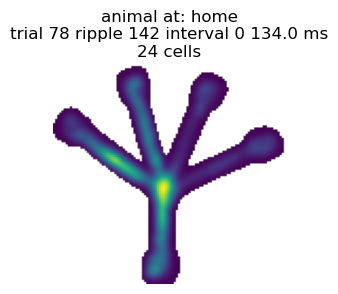

In [132]:
placefields_sum_all=[]

for ripple_ID in ripple_times.index:
    placefield_sum = plot_sum_place_field_by_ripple(ripple_ID, ripple_times, nwb_units_all, all_cells, placefields)
    if placefield_sum is None:
        continue
    for p in placefield_sum:
        placefields_sum_all.append(p)
    

In [ ]:
# Eliot
# ripple 15
# ripple 20
# ripple 119

In [77]:
# Lewis
# plot ripple 168
# ripple 176
# ripple 185
# ripple 186
# ripple 189
# ripple 202
# ripple 213

In [133]:
### plot snippet window
from spyglass.shijiegu.load import load_epoch_data, load_decode
import xarray as xr

from spyglass.shijiegu.Analysis_SGU import (TrialChoice,
                                   TrialChoiceReplay,
                                   RippleTimes,
                                   DecodeResultsLinear,get_linearization_map,
                                   find_ripple_times,mua_thresholder,sort_replays,
                                   classify_ripples,classify_ripple_content,
                                   load_everything,MUA,
                                   TetrodeNumber,NotExtendedTrialChoiceReplay,RippleTimesWithDecode,
                                  )
from spyglass.shijiegu.ripple_add_replay import plot_decode_spiking

In [134]:
# 2. load decode
encoding_set = "2Dheadspeed_above_4"
decoder_lk = "default_decoding_gpu_4armMaze_W20msO10ms"
decoder_ss = "default_decoding_gpu_4armMaze"

key_lk = {'nwb_file_name': nwb_copy_file_name,
          "encoding_set":encoding_set,"interval_list_name": session_name,
          "classifier_param_name": decoder_lk}

key_ss = {'nwb_file_name': nwb_copy_file_name,
          "encoding_set":encoding_set,"interval_list_name": session_name,
          "classifier_param_name": decoder_ss}

print(DecodeResultsLinear & key_lk)
print(DecodeResultsLinear & key_ss)

# load statescript decoder
decode_ss = load_decode(nwb_copy_file_name, session_name, key_ss["classifier_param_name"], encoding_set)
# load lk decoder
decode_lk = load_decode(nwb_copy_file_name, session_name, key_lk["classifier_param_name"], encoding_set)

*nwb_file_name *interval_list *classifier_pa *encoding_set  posterior 
+------------+ +------------+ +------------+ +------------+ +--------+
eliot20221021_ 02_Seq2Session default_decodi 2Dheadspeed_ab =BLOB=    
 (Total: 1)

*nwb_file_name *interval_list *classifier_pa *encoding_set  posterior 
+------------+ +------------+ +------------+ +------------+ +--------+
eliot20221021_ 02_Seq2Session default_decodi 2Dheadspeed_ab =BLOB=    
 (Total: 1)



In [136]:
# need to get theta_df, ripple_df, neural_df
(epoch_name,_,decode_ss,
 head_speed,head_orientation,linear_position_df,
 lfp_df,theta_df,ripple_df,neural_df,_) = load_epoch_data(nwb_copy_file_name,int(session_name[:2]),
                                                          key_ss["classifier_param_name"],
                                                          key_ss["encoding_set"],load_spike_flag = False)


[2025-11-12 21:27:43,723][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2025-11-12 21:27:43,735][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2025-11-12 21:27:43,739][WARNING]: Skipped checksum for file with hash: 4f1e870e-1a7d-11cb-9683-018f12baa832, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_0YUODHKC7Q.nwb
[2025-11-12 21:27:43,761][WARNING]: Skipped checksum for file with hash: 3de23236-9674-f9ed-0ecd-99660f486260, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_MS8U87CEGY.nwb
[2025-11-12 21:27:43,772][WARNING]: Skipped checksum for file with hash: 3de23236-9674-f9ed-0ecd-99660f486260, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_MS8U87CEGY.nwb
[2025-11-12 21:27:43,776][WARNING]: Skipped checksum for file with hash: 3d

epoch name 02_Seq2Session1
epoch_pos_name pos 1 valid times


[2025-11-12 21:27:43,901][WARNING]: Skipped checksum for file with hash: 65756212-f56e-fc3c-339a-369742efcaf5, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_O0JEUX5SSA.nwb
[2025-11-12 21:27:43,918][WARNING]: Skipped checksum for file with hash: 65756212-f56e-fc3c-339a-369742efcaf5, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_O0JEUX5SSA.nwb
[2025-11-12 21:27:43,922][WARNING]: Skipped checksum for file with hash: 65756212-f56e-fc3c-339a-369742efcaf5, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_O0JEUX5SSA.nwb
[2025-11-12 21:27:56,081][WARNING]: Skipped checksum for file with hash: 10f4d505-16a7-d851-ed33-b1666fc25ca5, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RI1AQDCPR0.nwb
[2025-11-12 21:27:56,097][WARNING]: Skipped checksum for file with hash: 10f4d505-16a7-d851-ed33-b1666fc25ca5, and path: /stelmo/nwb/analysis/eliot20221021/eliot20221021_RI1AQDCPR0.nwb
[2025-11-12 21:27:56,103][WARNING]: Skipped checksum for file with hash: 10

In [137]:
# MUA
mua_path=(MUA & {'nwb_file_name': nwb_copy_file_name,
                 'interval_list_name':session_name}).fetch1('mua_trace')
mua_xr = xr.open_dataset(mua_path)

## find tetrodes with signal
groups_with_cell=(SpikeSortingRecordingSelection & {
        'nwb_file_name' : nwb_copy_file_name}).fetch('sort_group_id')
groups_with_cell=np.setdiff1d(groups_with_cell,[100,101])
channel_IDs = list(neural_df.keys())
    
spikeColInd = {}
for g in groups_with_cell:
    spikeColInd_ = np.argwhere(np.isin(channel_IDs,(Electrode() &  {'nwb_file_name' : nwb_copy_file_name,
                                                     'electrode_group_name':str(g)}).fetch('electrode_id'))).ravel()
    spikeColInd[g] = spikeColInd_

AttributeError: 'NoneType' object has no attribute 'keys'

In [151]:
ripple_loc = 142
t0t1 = [[ripple_times.loc[ripple_loc].start_time,ripple_times.loc[ripple_loc].end_time],
        [ripple_times.loc[ripple_loc+1].start_time,ripple_times.loc[ripple_loc+1].end_time],
       ]
t0t1 = np.array(t0t1).reshape((-1,2))
plottimes = [t0t1[0,0]-0.5, t0t1[-1,-1]+0.5]

[array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]])]

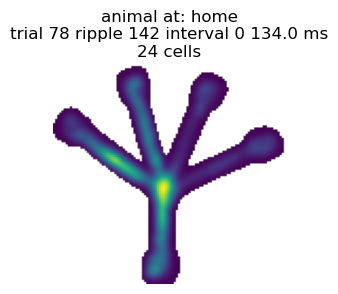

In [152]:
plot_sum_place_field_by_ripple(ripple_loc, ripple_times, nwb_units_all, all_cells, placefields)

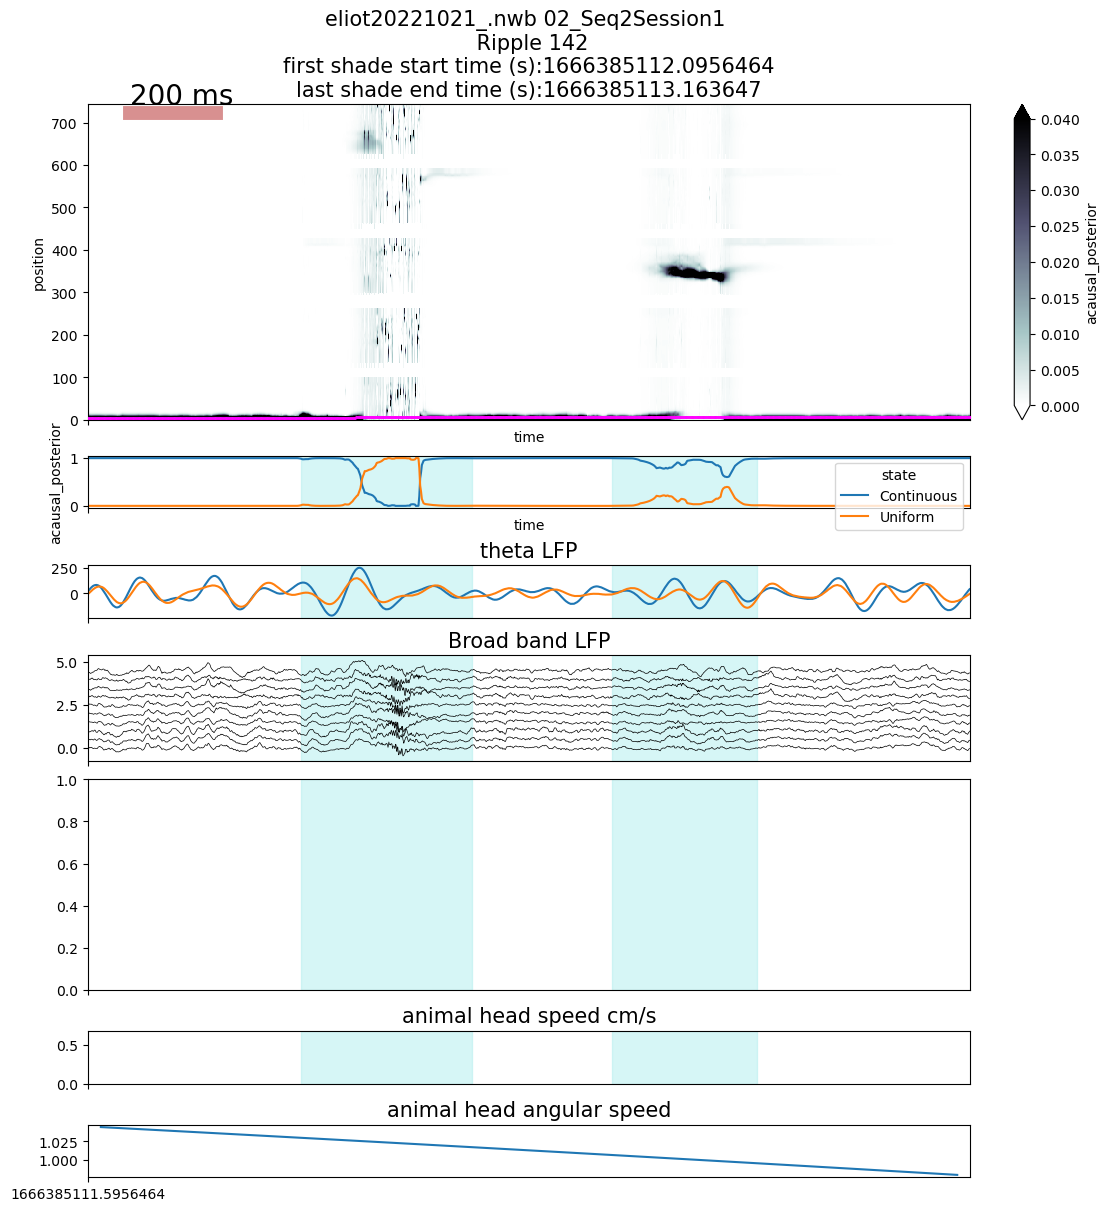

In [148]:
savefolder = "/home/shijiegu/Documents/spyglass/notebooks/FragmentedReplay/"
axes = plot_decode_spiking(plottimes,t0t1,linear_position_df,decode_ss,lfp_df,theta_df,
                    None,mua_xr,head_speed,head_orientation,
                    ripple_consensus_trace=None,
                    title=f"{nwb_copy_file_name} {session_name} \n Ripple {ripple_loc}",
                           savefolder=savefolder,
                           savename=f"{nwb_copy_file_name}_{session_name}_Ripple{ripple_loc}_{plottimes[0]}_{plottimes[1]}",
                    simple=True,tetrode2ind = {},mua_thresh = np.nan,
                           plot_spiking = False,
                    causal = False,likelihood = False, width = 11)

In [32]:
placefield_sum

0.0

### Place fields of exclusive fragmented cells

In [295]:
frag_units

[(5, 6),
 (5, 7),
 (5, 9),
 (13, 10),
 (13, 14),
 (14, 17),
 (16, 6),
 (17, 9),
 (26, 10),
 (26, 18),
 (30, 3)]

In [296]:
cell_list = frag_units
count_ratio = frag_count_ratio
        
cell_list_ = []  
placefields = {}
placefields_im = {}
mobility_spike_counts = {}
all_spike_counts = {}
peak_frs = {}
count_ratios = {}

for row_ind in range(len(cell_list)):
    print(row_ind)
    e = cell_list[row_ind][0]
    u = cell_list[row_ind][1]
    
    
    nwb_units = electrode_unit(nwb_copy_file_name,session_name,e,curation_id=1)
    print(e,u)
    
    placefield_im, _, _1, _2, _3, _4 = place_field(
        nwb_copy_file_name, session_name, pos_name, e, u,
        curation_id = 1, nwb_units = nwb_units,
        immobility = True,
        normalize = False)
    
    placefield, peak_fr, xbins, ybins, mobility_spike_count, all_spike_count = place_field(
        nwb_copy_file_name, session_name, pos_name, e, u,
        curation_id = 1, nwb_units = nwb_units,
        immobility = False,
        normalize = True)
    if mobility_spike_count < 5:
        continue
        
    cell_list_.append((e,u))
    count_ratios[(e,u)] = count_ratio[row_ind]
    
    placefields[(e,u)] = placefield
    placefields_im[(e,u)] = placefield_im
    peak_frs[(e,u)] = peak_fr
    mobility_spike_counts[(e,u)] = mobility_spike_count
    all_spike_counts[(e,u)] = all_spike_count

cell_list = cell_list_

0
5 6
spike num: 340
spike num: 340
1
5 7
spike num: 775
spike num: 775
2
5 9
spike num: 171
spike num: 171
3
13 10
spike num: 296
spike num: 296
4
13 14
spike num: 95
spike num: 95
5
14 17
spike num: 294
spike num: 294
6
16 6
spike num: 1628
spike num: 1628
7
17 9
spike num: 406
spike num: 406
8
26 10
spike num: 1536
spike num: 1536
9
26 18
spike num: 496
spike num: 496
10
30 3
spike num: 419
spike num: 419


In [297]:
#count_ratios

### 1. Place field

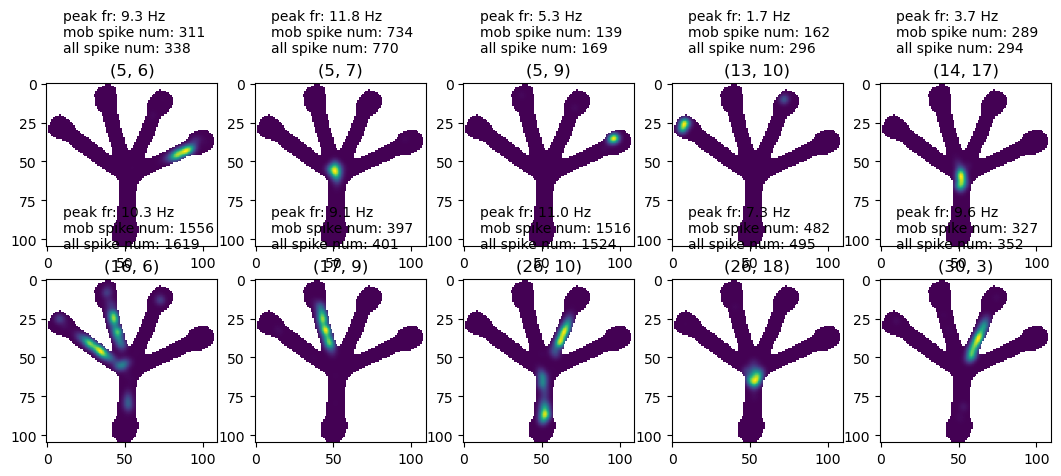

In [298]:
# low firing rate
row_num = int(np.ceil(len(cell_list)/5))
fig, axes = plt.subplots(row_num,5, figsize = (13,7 * row_num/3), squeeze = True)

ind = 0
for p in np.arange(len(cell_list)):
    
    (e,u) = cell_list[p]
    axes[np.unravel_index(ind, axes.shape)].imshow(placefields[(e,u)])
    axes[np.unravel_index(ind, axes.shape)].set_title(str((e,u)))
    axes[np.unravel_index(ind, axes.shape)].text(10,-20,"peak fr: "+str(round(peak_frs[(e,u)],1))+" Hz \n" + 
                                                 "mob spike num: "+str(mobility_spike_counts[e,u]) + "\n" +
                                                 "all spike num: "+str(all_spike_counts[e,u]))
    ind = ind + 1

for p in np.arange(ind, 10):
    axes[np.unravel_index(p, axes.shape)].set_axis_off()

### 2. immobility place field

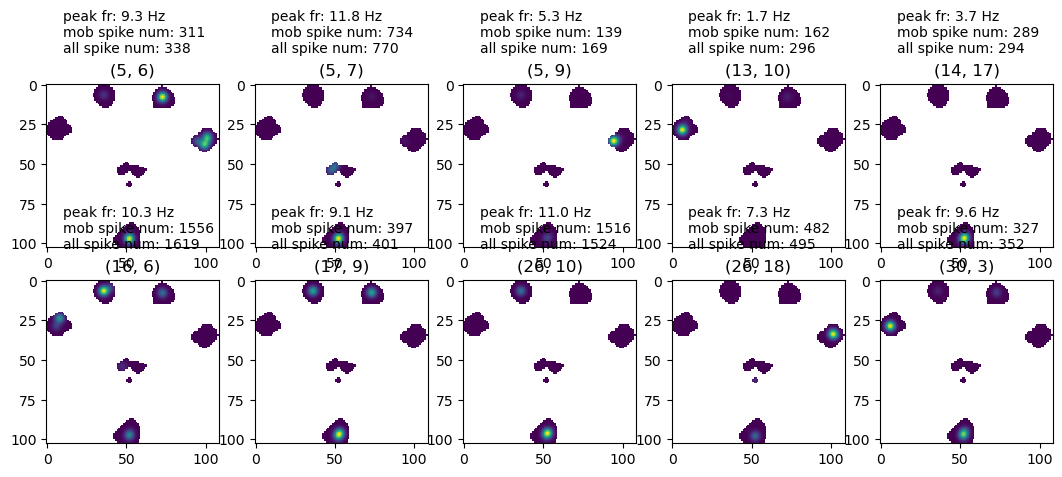

In [299]:
# low firing rate
row_num = int(np.ceil(len(cell_list)/5))
fig, axes = plt.subplots(row_num,5, figsize = (13,7 * row_num/3), squeeze = True)

ind = 0
for p in np.arange(len(cell_list)):
    
    (e,u) = cell_list[p]
    axes[np.unravel_index(ind, axes.shape)].imshow(placefields_im[(e,u)])
    axes[np.unravel_index(ind, axes.shape)].set_title(str((e,u)))
    axes[np.unravel_index(ind, axes.shape)].text(10,-20,"peak fr: "+str(round(peak_frs[(e,u)],1))+" Hz \n" + 
                                                 "mob spike num: "+str(mobility_spike_counts[e,u]) + "\n" +
                                                 "all spike num: "+str(all_spike_counts[e,u]))
    ind = ind + 1

for p in np.arange(ind, 10):
    axes[np.unravel_index(p, axes.shape)].set_axis_off()

In [204]:
pfr = [peak_frs[key] for key in peak_frs.keys()]    

In [205]:
pfr_index = np.argsort(pfr)

In [206]:
pfr_index[0]

1

IndexError: index 5 is out of bounds for axis 0 with size 5

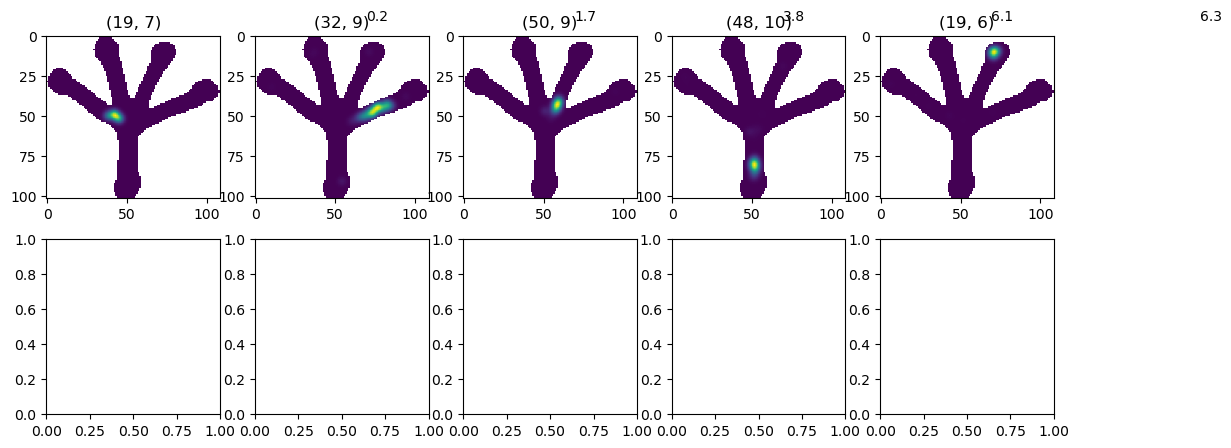

In [207]:
# low firing rate
fig, axes = plt.subplots(2,5, figsize = (13,5), squeeze = True)

ind = 0
for p in np.arange(10):
    
    (e,u) = cell_list[pfr_index[p]]
    axes[np.unravel_index(ind, axes.shape)].imshow(placefields[(e,u)])
    axes[np.unravel_index(ind, axes.shape)].set_title(str((e,u)))
    axes[np.unravel_index(ind, axes.shape)].text(200,-10,round(peak_frs[(e,u)],1))
    ind = ind + 1

In [ ]:
# high firing rate
fig, axes = plt.subplots(2,5, figsize = (13,5), squeeze = True)

ind = 0
for p in np.arange(10):
    
    (e,u) = cell_list[pfr_index[0+p]]
    axes[np.unravel_index(ind, axes.shape)].imshow(placefields[(e,u)])
    axes[np.unravel_index(ind, axes.shape)].set_title(str((e,u)))
    axes[np.unravel_index(ind, axes.shape)].text(200,-10,round(peak_frs[(e,u)],1))
    ind = ind + 1

Text(200, 25, '17.2')

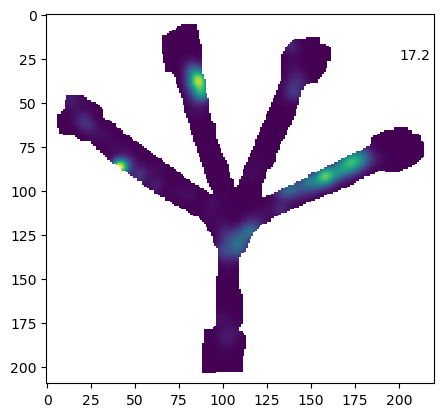

In [107]:
e = 14
u = 9
# (14,9), (13,7), (16,6)
placefield, peak_fr, xbins, ybins, mobility_spike_count, all_spike_count = place_field(nwb_copy_file_name, session_name, pos_name, e, u)
plt.imshow(placefield)
plt.text(200,25,np.round(peak_fr,1))

Text(200, 25, '35.4')

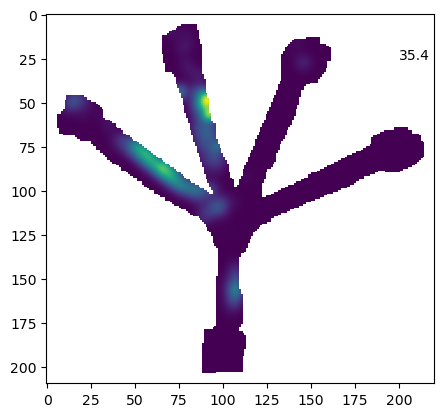

In [63]:
e = 16
u = 6

plt.imshow(placefields[(e,u)])
plt.text(200,25,np.round(peak_frs[(e,u)],1))

In [124]:
#peak normalize placefield
normalized_placefields = {}
for row_ind in range(len(cell_list)):
    print(row_ind)
    e = cell_list[row_ind][0]
    u = cell_list[row_ind][1]
    normalized_placefields[(e,u)] = placefields[(e,u)]/np.nanmax(placefields[(e,u)])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89


In [117]:
count_ratio, firing_rate_F, firing_rate_C = find_spike_count_ratio(nwb_units_all,ripple_times)

In [118]:
cells_frag, cells_cont = classify_cells(firing_rate_F, firing_rate_C)

electrode 0 unit 3
during fragmented replay:  7.304430676138095 31.0
during cont replay:  3.709264109928835 84.0
electrode 0 unit 4
during fragmented replay:  0.23562679600445469 1.0
during cont replay:  0.04415790607058137 1.0
electrode 0 unit 6
during fragmented replay:  2.8275215520534562 12.0
during cont replay:  1.9871057731761617 45.0
electrode 0 unit 7
during fragmented replay:  3.5344019400668203 15.0
during cont replay:  0.7506844031998833 17.0
electrode 0 unit 8
during fragmented replay:  1.1781339800222734 5.0
during cont replay:  0.1324737182117441 3.0
electrode 2 unit 3
during fragmented replay:  2.356267960044547 10.0
during cont replay:  1.1481055578351156 26.0
electrode 5 unit 2
during fragmented replay:  0.0 0.0
during cont replay:  0.9273160274822088 21.0
electrode 5 unit 5
during fragmented replay:  2.120641164040092 9.0
during cont replay:  0.30910534249406957 7.0
electrode 5 unit 6
during fragmented replay:  0.23562679600445469 1.0
during cont replay:  0.0 0.0
elec

In [122]:
cell_non_frag = list(set(cell_list)-set(cells_frag))

array([31.24993667, 15.62496834, 15.62496834, 15.62496834])

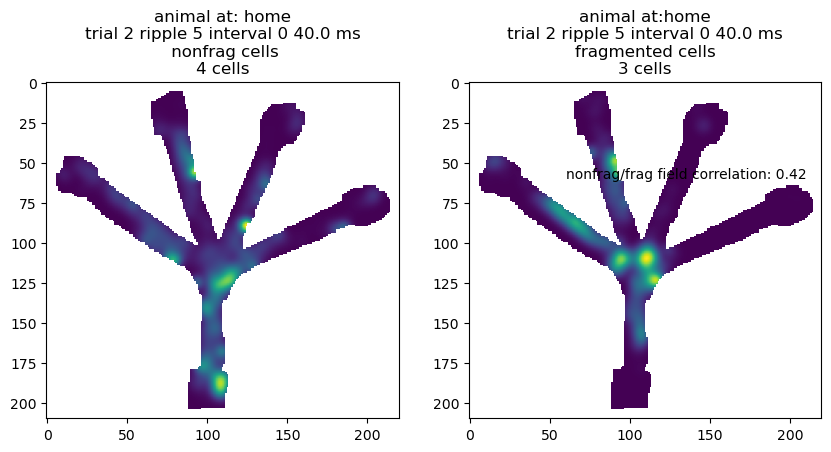

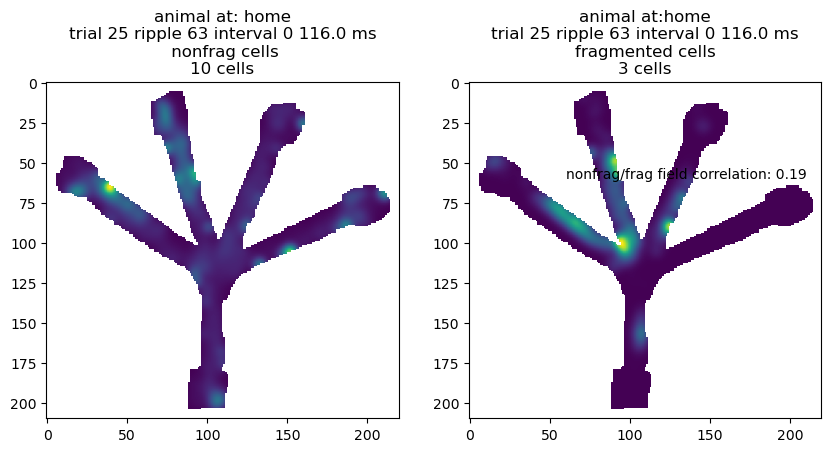

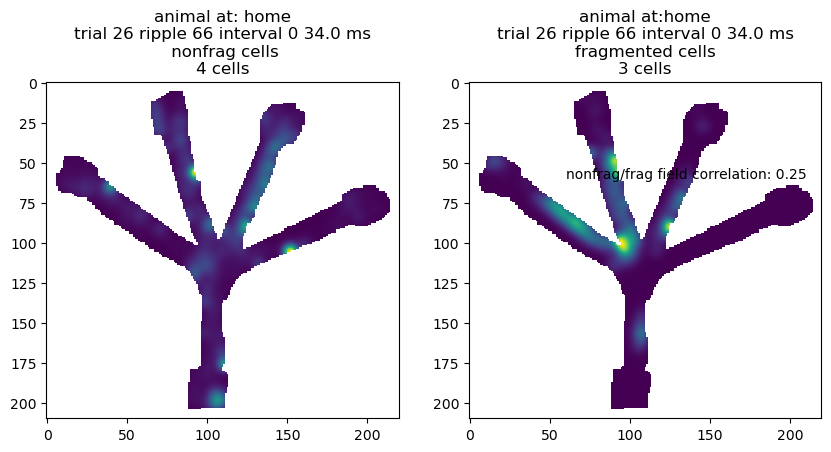

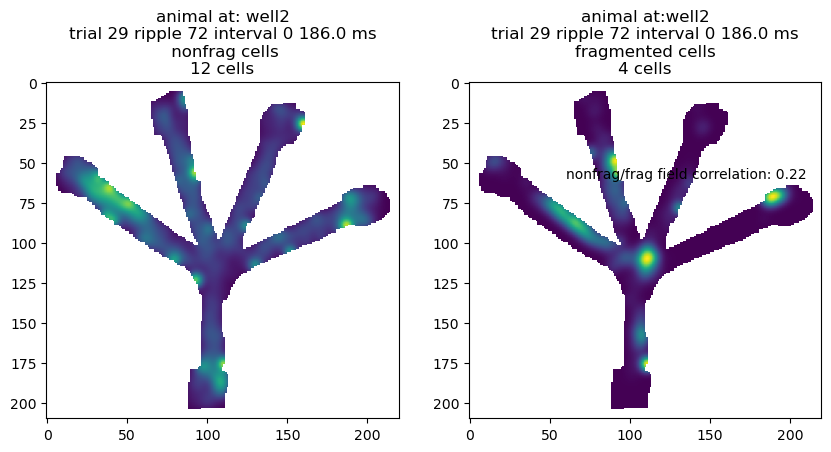

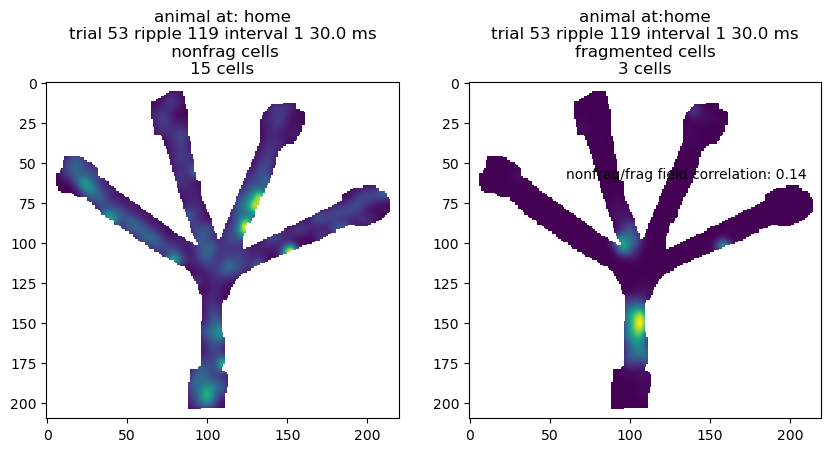

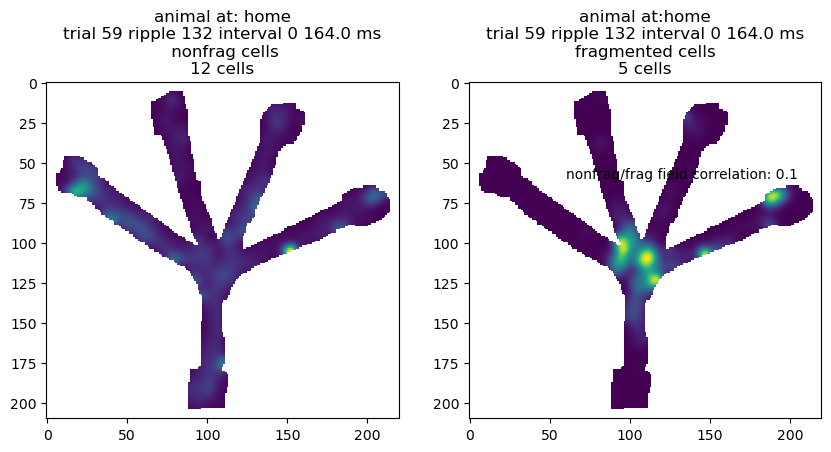

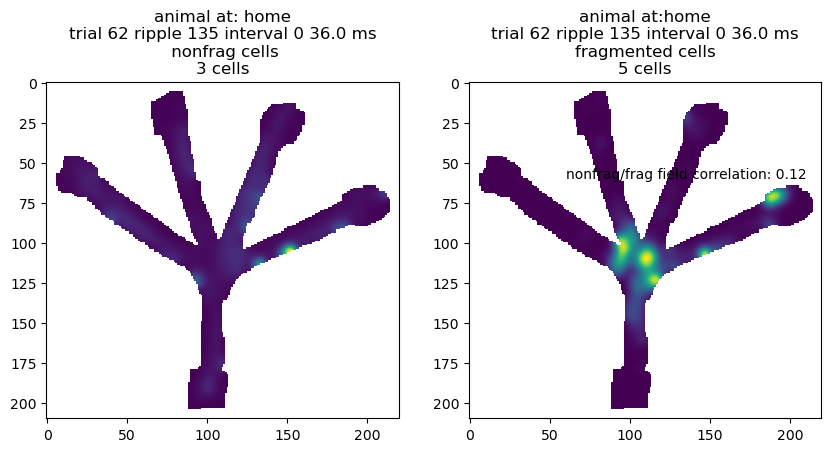

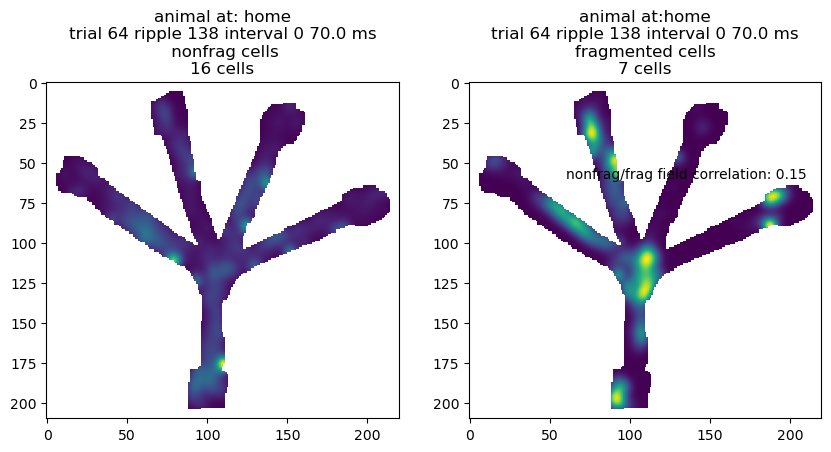

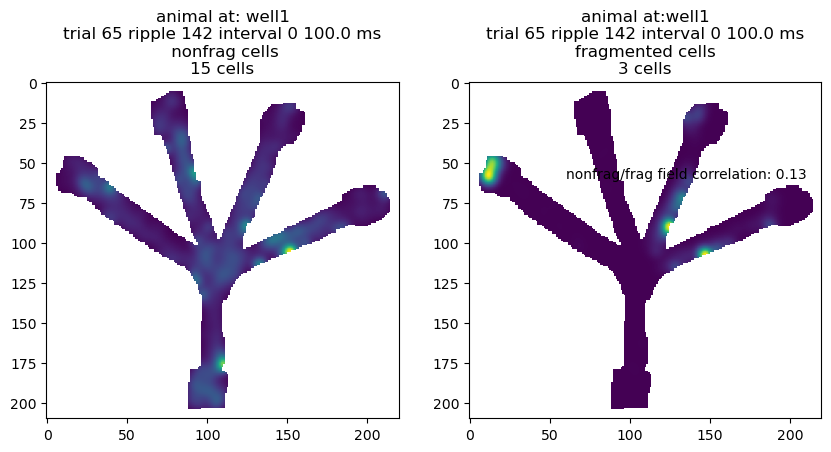

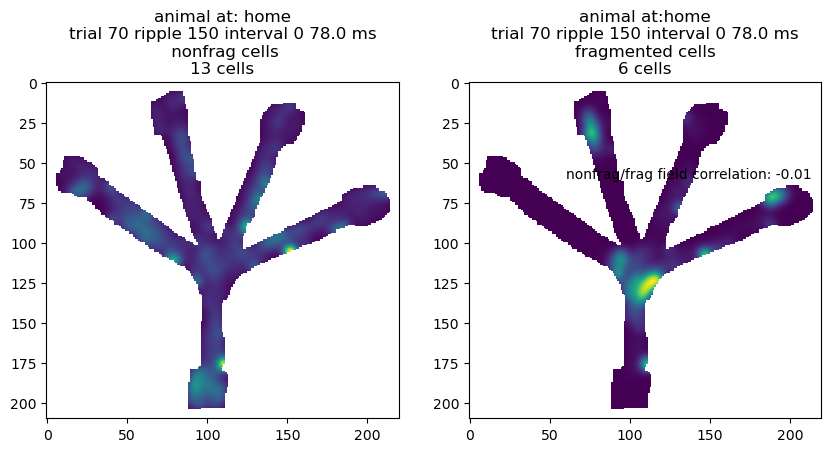

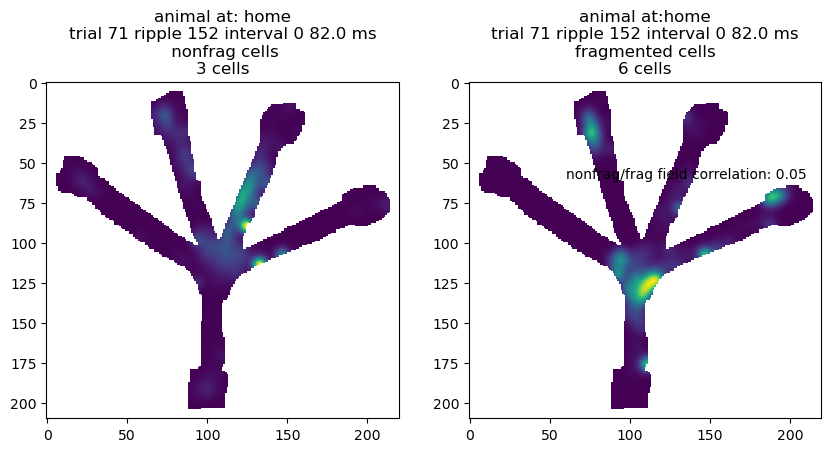

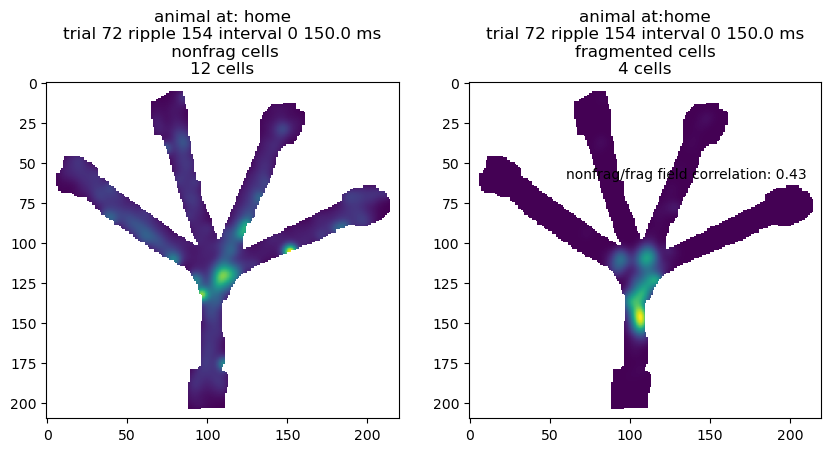

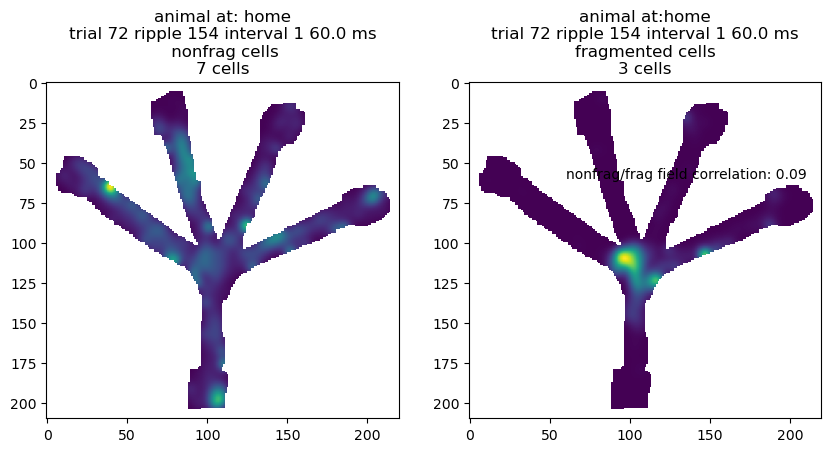

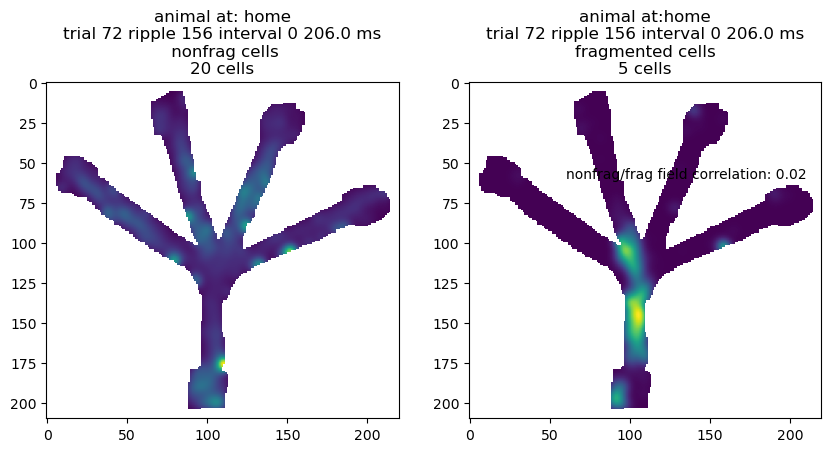

In [125]:
placefields_intvl_sum_cont_all=[]
placefields_intvl_sum_frag_all=[]

for ripple_ID in ripple_times.index:
    intvls = ripple_times.loc[ripple_ID].frag_intvl	
    trial = ripple_times.loc[ripple_ID].trial_number
    location = ripple_times.loc[ripple_ID].animal_location
    if len(intvls) == 0:
        continue
    
    for intvl_ind in range(intvls.shape[0]):
        intvl = intvls[intvl_ind]
        
        duration = str(round(float(np.diff(intvl))*1000,1)) + ' ms'
        
        firing_cont = find_spikes(nwb_units_all,cell_non_frag,intvl).ravel()
        activate_cell_cont = np.array(cell_non_frag)[firing_cont > 0]
        weights = firing_cont[firing_cont>0]
        if len(activate_cell_cont) == 0:
            continue
        placefields_intvl_sum_cont, cell_num_cont = sum_place_field_by_weight(normalized_placefields,activate_cell_cont,weights)

        firing_frag = find_spikes(nwb_units_all,cells_frag,intvl).ravel()
        activate_cell_frag = np.array(cells_frag)[firing_frag > 0]
        if len(activate_cell_frag) > 0:
            placefields_intvl_sum_frag, cell_num_frag = sum_place_field(normalized_placefields,activate_cell_frag)

        if cell_num_cont > 2 and cell_num_frag > 2:
            placefields_intvl_sum_cont_all.append(placefields_intvl_sum_cont)
            placefields_intvl_sum_frag_all.append(placefields_intvl_sum_frag)
            
            valid_ind = ~np.isnan(placefields_intvl_sum_cont)
            field_cont = placefields_intvl_sum_cont[valid_ind]
            field_frag = placefields_intvl_sum_frag[valid_ind]
            corr = np.corrcoef(field_cont, field_frag)[0,1]
            
            fig, axes = plt.subplots(1,2,figsize = (10,5),sharex = 1,squeeze = False)
            axes[0,0].imshow(placefields_intvl_sum_cont)
            axes[0,0].set_title('animal at: '+location+
                '\ntrial '+str(trial)+' ripple '+str(ripple_ID)+' interval '+ str(intvl_ind)+' '+duration+
                                        '\n nonfrag cells\n'+str(cell_num_cont)+' cells')
            axes[0,1].text(60,60,'nonfrag/frag field correlation: '+str(round(corr,2)))
            
            
            axes[0,1].imshow(placefields_intvl_sum_frag)
            axes[0,1].set_title('animal at:'+location+
                    '\ntrial '+str(trial)+' ripple '+str(ripple_ID)+' interval '+ str(intvl_ind)+' '+duration+
                                        '\nfragmented cells\n'+str(cell_num_frag)+' cells')

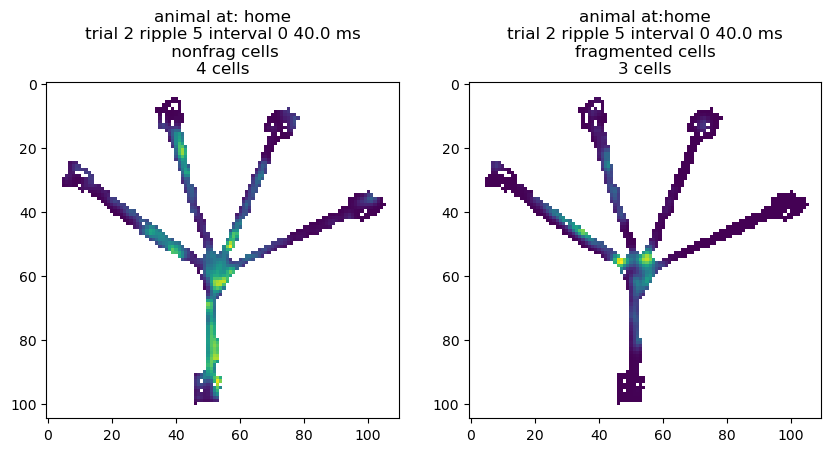

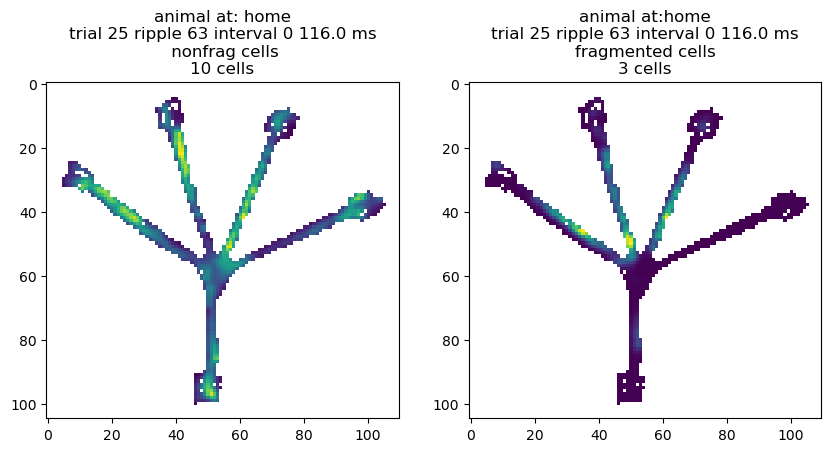

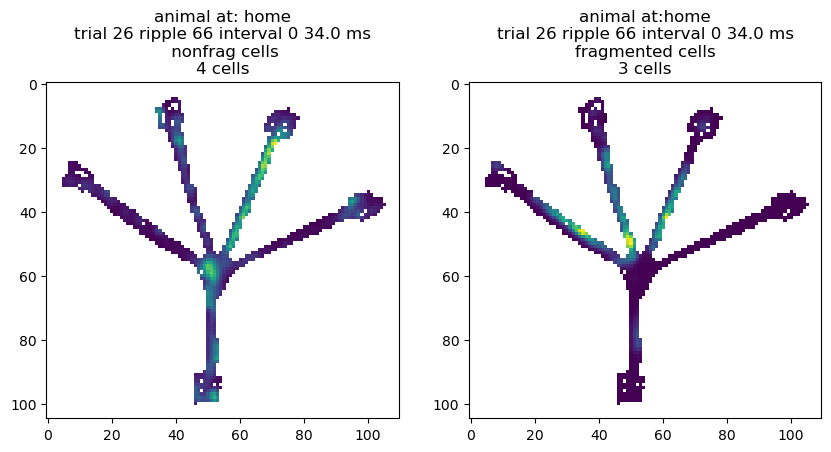

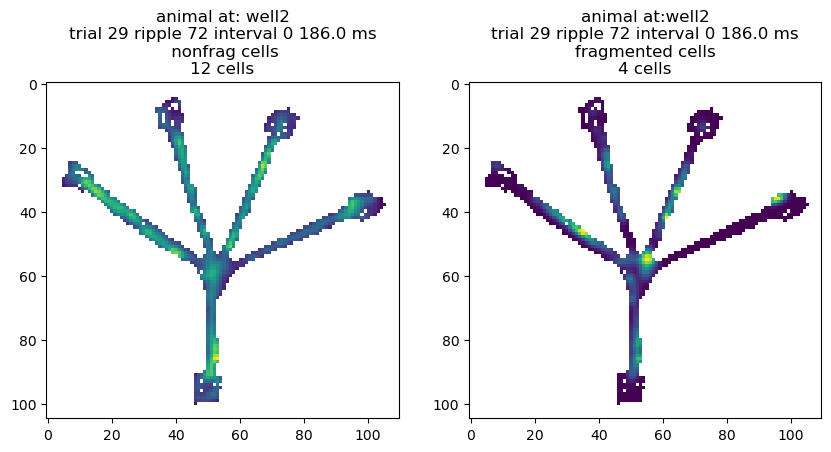

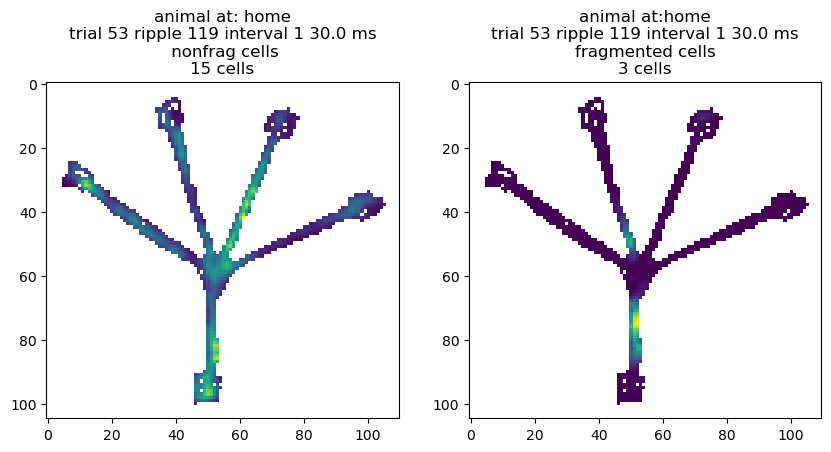

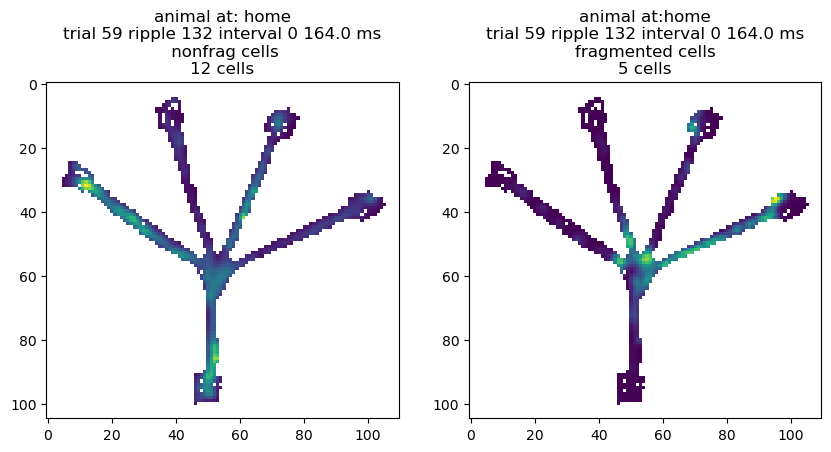

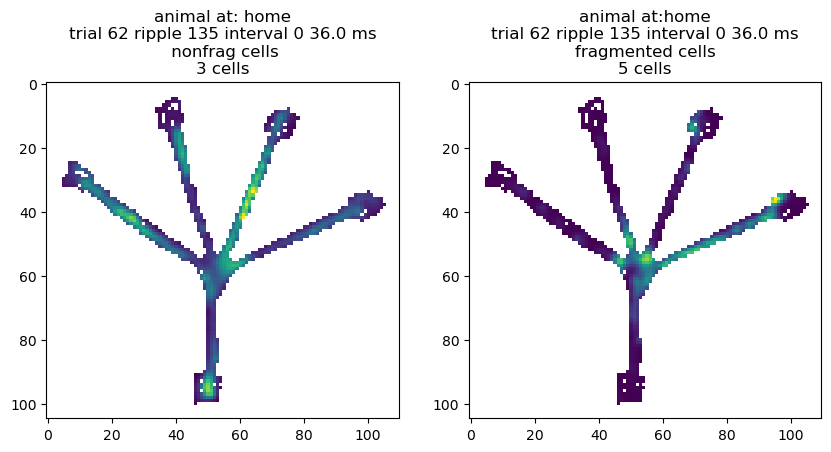

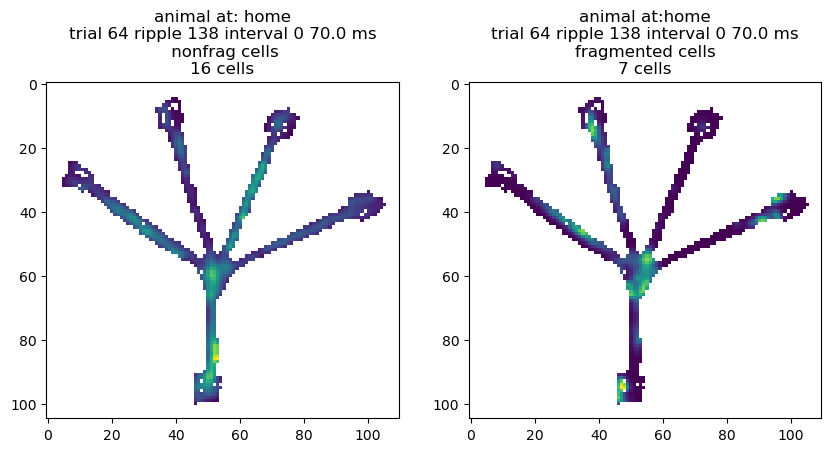

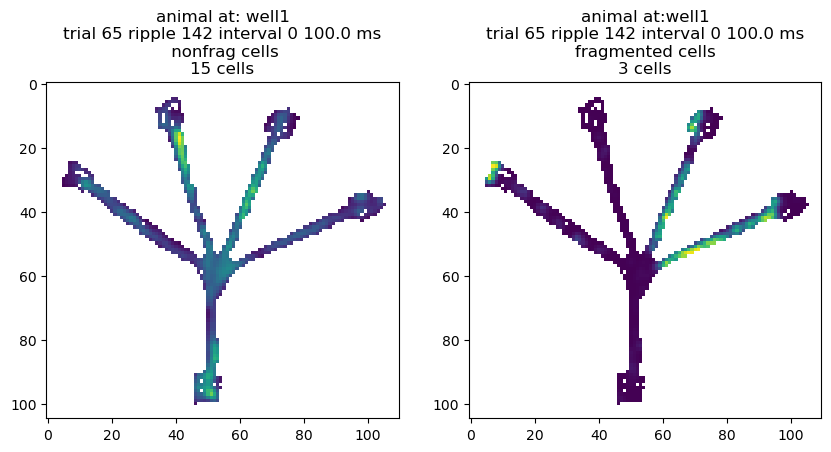

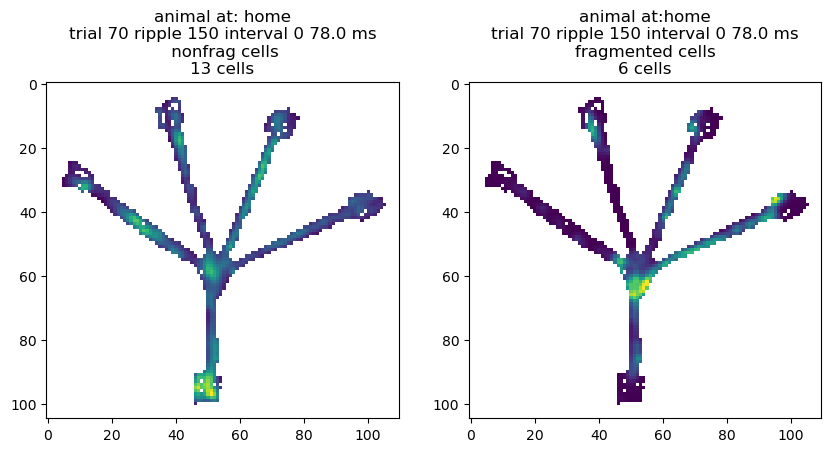

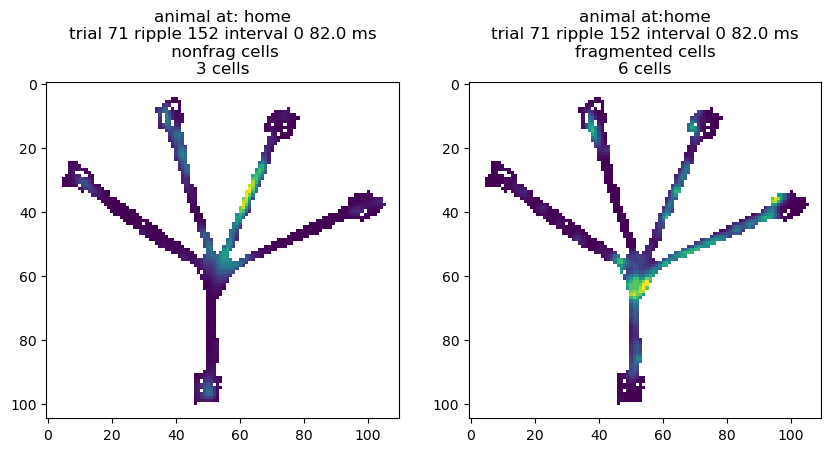

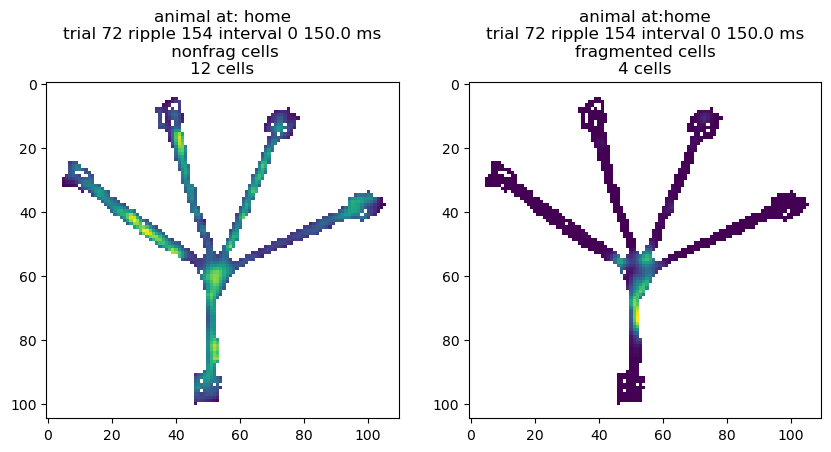

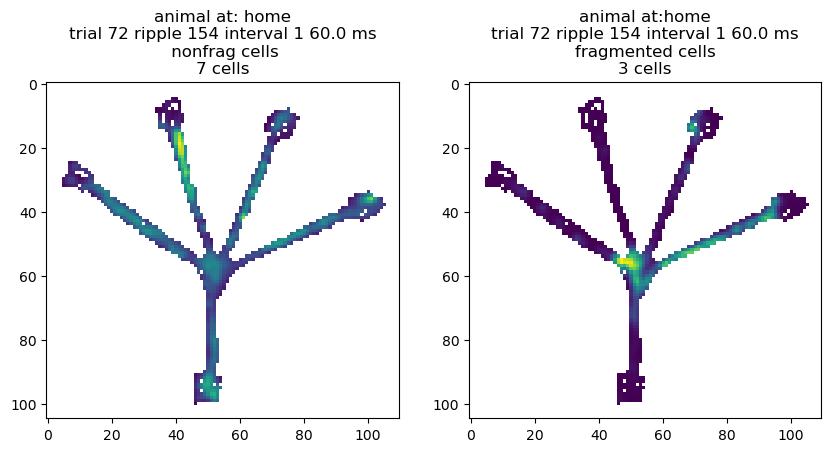

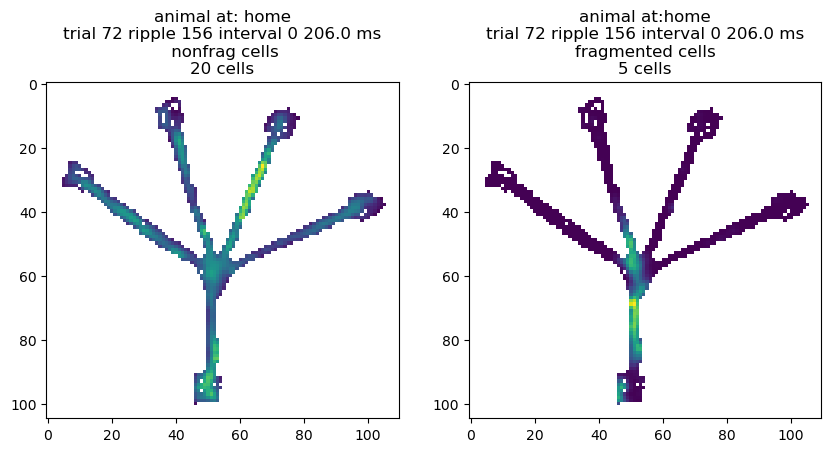

In [149]:
for ripple_ID in ripple_times.index:
    intvls = ripple_times.loc[ripple_ID].frag_intvl	
    trial = ripple_times.loc[ripple_ID].trial_number
    location = ripple_times.loc[ripple_ID].animal_location
    if len(intvls) == 0:
        continue
    
    for intvl_ind in range(intvls.shape[0]):
        intvl = intvls[intvl_ind]
        
        duration = str(round(float(np.diff(intvl))*1000,1)) + ' ms'
        
        firing_cont = find_spikes(nwb_units_all,cell_non_frag,intvl).ravel()
        activate_cell_cont = np.array(cell_non_frag)[firing_cont > 0]
        weights = firing_cont[firing_cont>0]
        if len(activate_cell_cont) == 0:
            continue
        placefields_intvl_sum_cont, cell_num_cont = sum_place_field(normalized_placefields,activate_cell_cont)

        firing_frag = find_spikes(nwb_units_all,cells_frag,intvl).ravel()
        activate_cell_frag = np.array(cells_frag)[firing_frag > 0]
        if len(activate_cell_frag) > 0:
            placefields_intvl_sum_frag, cell_num_frag = sum_place_field(normalized_placefields,activate_cell_frag)

        if cell_num_cont > 2 and cell_num_frag > 2:
            fig, axes = plt.subplots(1,2,figsize = (10,5),sharex = 1,squeeze = False)
            axes[0,0].imshow(placefields_intvl_sum_cont)
            axes[0,0].set_title('animal at: '+location+
                '\ntrial '+str(trial)+' ripple '+str(ripple_ID)+' interval '+ str(intvl_ind)+' '+duration+
                                        '\n nonfrag cells\n'+str(cell_num_cont)+' cells')
            
            
            axes[0,1].imshow(placefields_intvl_sum_frag)
            axes[0,1].set_title('animal at:'+location+
                    '\ntrial '+str(trial)+' ripple '+str(ripple_ID)+' interval '+ str(intvl_ind)+' '+duration+
                                        '\nfragmented cells\n'+str(cell_num_frag)+' cells')

In [126]:
place_corr = []

for i in range(len(placefields_intvl_sum_cont_all)):
    print(i)
    field_cont = placefields_intvl_sum_cont_all[i]
    field_frag = placefields_intvl_sum_frag_all[i]

    # mean subtraction
    #field_cont = field_cont - np.nanmean(field_cont)
    #field_frag = field_frag - np.nanmean(field_frag)

    valid_ind = ~np.isnan(field_cont)
    field_cont = field_cont[valid_ind]
    field_frag = field_frag[valid_ind]

    #field_cont = field_cont > np.nanmedian(field_cont) #/(np.max(field_cont) - np.min(field_cont))
    #field_frag = field_frag > np.nanmedian(field_frag) #/(np.max(field_frag) - np.min(field_frag))

    #field_cont = field_cont/np.linalg.norm(field_cont)
    #field_frag = field_frag/np.linalg.norm(field_frag)
    
    place_corr.append(np.corrcoef(field_cont, field_frag)[0,1])
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [127]:
# permute
placefields_intvl_sum_all = placefields_intvl_sum_cont_all + placefields_intvl_sum_frag_all

place_corr_B =[]

for b in range(1000):
    place_corr_b = []
    
    for i in range(len(placefields_intvl_sum_cont_all)):
        (ii,jj) = np.random.choice(np.arange(len(placefields_intvl_sum_all)),replace = False, size = 2)
        
        field_cont = placefields_intvl_sum_all[ii]
        field_frag = placefields_intvl_sum_all[jj]
    
        # mean subtraction
        #field_cont = field_cont - np.nanmean(field_cont)
        #field_frag = field_frag - np.nanmean(field_frag)
    
        valid_ind = ~np.isnan(field_cont)
        field_cont = field_cont[valid_ind]
        field_frag = field_frag[valid_ind]
    
        #field_cont = field_cont > np.nanmedian(field_cont) #/(np.max(field_cont) - np.min(field_cont))
        #field_frag = field_frag > np.nanmedian(field_frag) #/(np.max(field_frag) - np.min(field_frag))
    
        #field_cont = field_cont/np.linalg.norm(field_cont)
        #field_frag = field_frag/np.linalg.norm(field_frag)
        
        place_corr_b.append(np.corrcoef(field_cont, field_frag)[0,1])
    place_corr_B.append(place_corr_b)

Text(0.5, 1.0, 'field summation correlation coef')

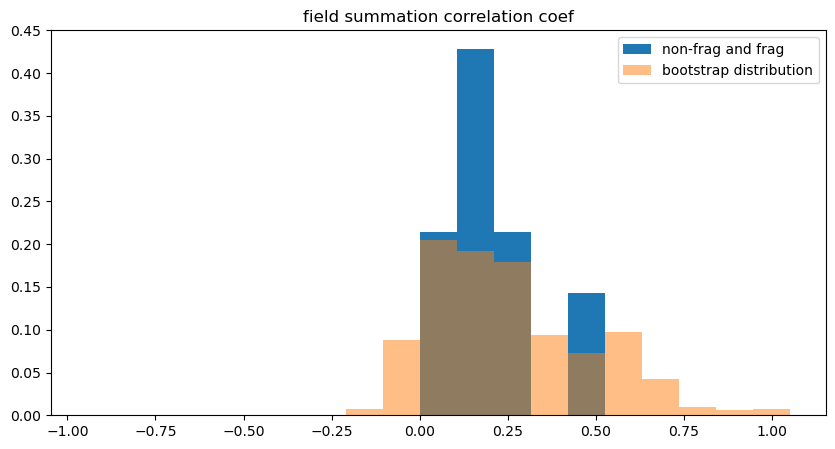

In [128]:
fig, axes = plt.subplots(1,1,figsize = (10,5),sharex = 1,squeeze = True)
data, axis = np.histogram(place_corr,np.linspace(-1,1,20),
                          weights = np.ones(len(place_corr))/len(place_corr),
                          )
axes.bar(axis[1:],data,width = axis[1]-axis[0],label = 'non-frag and frag')

place_corr_b = np.concatenate(place_corr_B)
data_b, axis = np.histogram(place_corr_b,np.linspace(-1,1,20),weights = np.ones(len(place_corr_b))/len(place_corr_b))
axes.bar(axis[1:],data_b,width = axis[1]-axis[0],alpha = 0.5,label = 'bootstrap distribution')

axes.legend()
axes.set_title('field summation correlation coef')